# Heat Pump Optimization - Deterministic MPC

This notebook demonstrates how **Model Predictive Control (MPC)** can optimize heat pump operation to minimize electricity costs while meeting thermal comfort requirements.

## Overview

**What this notebook does:**
- Loads plant data with thermal load and outdoor temperature profiles
- Calculates baseline costs for uncontrolled EV charging (baseline case)
- Applies deterministic MPC optimization to schedule heat pump operation optimally
- Compares optimized vs baseline results to quantify cost savings

**Key optimization objectives:**
- Minimize total electricity costs (energy + peak charges + spot prices)
- Optimize heat pump operation based on thermal load and outdoor temperature
- Shift heat pump operation to low-price periods
- Reduce peak power demand to lower capacity charges
- Utilize PV production when available
- Meet thermal comfort requirements

**Expected outcomes:**
- Significant cost reduction through intelligent load shifting
- Lower peak power demand
- Better alignment with renewable energy production
- Detailed visualizations comparing baseline vs optimized strategies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Add src to path
sys.path.append(str(Path("..") / "src"))

from optimization import deterministic_mpc_hp
from billing import load_billing_config, calculate_monthly_bills, calculate_monthly_injection_bills
from heat_pump_load import calculate_heat_pump_load

print("Libraries imported successfully")

Libraries imported successfully


## Load Data

This section loads the plant data from `plant1.csv`, which contains the same dataset used in `01_benchmark.ipynb`.

**What you'll see:**
- **Data summary** showing:
  - Total number of records (15-minute intervals for one year)
  - Available columns (timestamp, grid consumption, prices, PV production, EV data, thermal load, outdoor temperature, etc.)
  - Date range of the dataset
  - Statistical summary of key variables:
    - Grid consumption (kWh)
    - PV production (kWh)
    - Grid injection (kWh)
    - EV charging (kWh)
    - Inflexible load (kWh)
    - Thermal load (kWh)
    - Outdoor temperature (°C)
    - Electricity prices (€/MWh)

This data provides the foundation for both baseline cost calculation and optimization.

In [2]:
# Load plant data (same as 01_benchmark.ipynb)
df = pd.read_csv("../data/plant1.csv", parse_dates=["timestamp"])

# Normalize column names (handles accidental leading/trailing spaces)
df.columns = df.columns.str.strip()

print(f"Data loaded: {len(df)} rows")
print(f"Columns: {list(df.columns)}")
print(f"\nDate range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"\nData summary:")
print(df[['grid_consumption', 'pv_production', 'grid_injection', 'ev', 'inflex_load', 'thermal_load', 'outdoor_temperature', 'price']].describe())

Data loaded: 35040 rows
Columns: ['timestamp', 'grid_consumption', 'price', 'pv_production', 'grid_injection', 'total_consumption', 'ev', 'inflex_load', 'grid_consumption_excl_ev', 'thermal_load', 'outdoor_temperature']

Date range: 2025-01-01 00:00:00+01:00 to 2025-12-31 23:45:00+01:00

Data summary:
       grid_consumption  pv_production  grid_injection            ev  \
count      35040.000000   35040.000000    35040.000000  35040.000000   
mean         330.554338      51.857346        0.004944      9.856753   
std          155.762869      87.539674        0.237750     20.675190   
min            0.000000       0.000000        0.000000      0.000000   
25%          184.625000       0.000000        0.000000      0.000000   
50%          372.750000       0.000000        0.000000      0.000000   
75%          456.750000      75.425000        0.000000      8.028882   
max          705.250000     424.100000       19.250000    148.400000   

        inflex_load  thermal_load  outdoor_tempe

## Calculate Non-Optimized Costs (Baseline)

This section calculates the electricity costs for the **baseline scenario**: uncontrolled EV charging (no EV optimization) and **no heat pump** (heat pump excluded). This serves as the baseline for comparison.

**What you'll see:**
- **Monthly billing breakdown** for the baseline scenario showing:
  - Energy costs (volume × energy rate)
  - Spot price costs (variable electricity prices)
  - Peak-based costs (monthly peak power charges)
  - Injection revenue (from excess PV production)
  - Net total costs

**Baseline scenario:**
- EV charging: uncontrolled (baseline pattern from data)
- Heat pump: excluded (no heat pump operation)

Compare total costs between this baseline and the optimized scenario (uncontrolled EV + optimized heat pump).

In [3]:
# Calculate baseline costs: uncontrolled EV charging, no heat pump
# The baseline scenario uses:
# - Uncontrolled EV charging (from grid_consumption in data)
# - No heat pump (heat pump excluded)
# This matches the benchmark analysis from 01_benchmark.ipynb
# We use the actual grid_consumption which includes uncontrolled EV charging
#
# Conservative access power (same as notebook 02 / notebook 09 heuristic):
# access_power_conservative[m] = max(observed monthly peak up to m-1) + 20 kW

from IPython.display import display

config_path = "../config/billing.yaml"
config = load_billing_config(config_path)

df_baseline = df.copy()

# Month labels must match billing.py. CSV has mixed +01:00 (CET) and +02:00 (CEST).
ts_raw = df_baseline["timestamp"]
if ts_raw.dtype == "object" or isinstance(
    ts_raw.iloc[0] if len(ts_raw) else None, str
):
    ts_naive = ts_raw.astype(str).str.replace(r"[+-]\d{2}:\d{2}$", "", regex=True)
    ts_naive = pd.to_datetime(ts_naive, errors="coerce")
else:
    ts_naive = pd.to_datetime(ts_raw, errors="coerce")
    if ts_naive.dt.tz is not None:
        ts_naive = ts_naive.dt.tz_localize(None)

naive_timestamps = pd.to_datetime(
    ts_naive.dt.strftime("%Y-%m-%d %H:%M:%S"),
    format="%Y-%m-%d %H:%M:%S",
)
df_baseline["month"] = naive_timestamps.dt.to_period("M")

MARGIN_KW = 20.0
BASELINE_2024_PEAK_GRID_KW = 2663.5

months_2025 = pd.period_range("2025-01", "2025-12", freq="M")
monthly_peak_baseline_kw = (
    (df_baseline.groupby("month")["grid_consumption"].max() * 4.0)
    .reindex(months_2025)
    .fillna(0.0)
)

cummax_M_minus_1_kw = monthly_peak_baseline_kw.cummax().shift(1)
cummax_M_minus_1_kw.loc[months_2025.min()] = BASELINE_2024_PEAK_GRID_KW
cummax_M_minus_1_kw = cummax_M_minus_1_kw.fillna(BASELINE_2024_PEAK_GRID_KW)

access_power_conservative = cummax_M_minus_1_kw + MARGIN_KW

df_baseline["baseline_access_power_conservative"] = (
    df_baseline["month"].map(access_power_conservative.to_dict()).astype(float)
)

baseline_bills = calculate_monthly_bills(
    df_baseline,
    config,
    access_power_col="baseline_access_power_conservative",
)

ap_diagnostics = pd.DataFrame(
    {
        "baseline_monthly_peak_kw": monthly_peak_baseline_kw.values,
        "cummax_M_minus_1_kw": cummax_M_minus_1_kw.values,
        "access_power_conservative_kw": access_power_conservative.values,
    },
    index=months_2025,
)
print("Conservative baseline access power (previous max + 20 kW):")
display(ap_diagnostics.round(1))

print(f"\nBaseline access power (January): {baseline_bills['access_power_kw'].iloc[0]:.2f} kW")
print(f"Baseline peak cost total: {baseline_bills['peak_based_cost_eur'].sum():.2f} EUR")

baseline_injection = calculate_monthly_injection_bills(df_baseline, config)
baseline_injection_revenue = baseline_injection['injection_net_revenue_eur'].sum()
baseline_net_total = baseline_bills['total_cost_eur'].sum() - baseline_injection_revenue

print("="*80)
print("BASELINE (Non-Optimized, incl. uncontrolled EV charging, excl. heat pump) COSTS")
print("="*80)
print(f"\nTotal Energy Cost:     {baseline_bills['energy_cost_eur'].sum():>15,.2f} EUR")
print(f"Total Spot Cost:       {baseline_bills['spot_cost_eur'].sum():>15,.2f} EUR")
print(f"Total Peak Cost:       {baseline_bills['peak_based_cost_eur'].sum():>15,.2f} EUR")
print(f"Injection Revenue:     {baseline_injection_revenue:>15,.2f} EUR")
print(f"{'-'*50}")
print(f"NET TOTAL COST:        {baseline_net_total:>15,.2f} EUR")
print("="*80)

Conservative baseline access power (previous max + 20 kW):


,baseline_monthly_peak_kw,cummax_M_minus_1_kw,access_power_conservative_kw
2025-01,2684.5,2663.5,2683.5
2025-02,2726.5,2684.5,2704.5
2025-03,2527.0,2726.5,2746.5
2025-04,2506.0,2726.5,2746.5
2025-05,2485.0,2726.5,2746.5
2025-06,2411.5,2726.5,2746.5
2025-07,2362.5,2726.5,2746.5
2025-08,2240.0,2726.5,2746.5
2025-09,2604.0,2726.5,2746.5
2025-10,2821.0,2726.5,2746.5



Baseline access power (January): 2683.50 kW
Baseline peak cost total: 231006.05 EUR
BASELINE (Non-Optimized, incl. uncontrolled EV charging, excl. heat pump) COSTS

Total Energy Cost:          375,450.30 EUR
Total Spot Cost:          1,075,304.89 EUR
Total Peak Cost:            231,006.05 EUR
Injection Revenue:               10.02 EUR
--------------------------------------------------
NET TOTAL COST:           1,681,751.22 EUR


## Calculate Heat Pump Load (Uncontrolled)

This section calculates the electrical load of the heat pump based on thermal load demand and outdoor temperature.

**Process:**
1. Load HP configuration (COP data, capacity) from `hp.yaml`
2. Load thermal load and outdoor temperature from `plant1.csv`
3. Interpolate COP for each timestep based on outdoor temperature
4. Calculate electrical power = thermal_power / COP
5. Convert to electrical load (kWh per 15-min interval)
6. Save to `output/uncontrolled_hp.csv`

**Formulas:**
- COP = f(T_outdoor) [interpolated from datasheet values]
- Thermal power (kW) = Thermal load (kWh) / 0.25 h
- Electrical power (kW) = Thermal power (kW) / COP
- Electrical load (kWh) = Electrical power (kW) × 0.25 h

In [4]:
# Calculate heat pump electrical load
hp_load_df = calculate_heat_pump_load(
    data_path="../data/plant1.csv",
    config_path="../config/hp.yaml",
    output_path="../output/uncontrolled_hp.csv"
)

# Display summary
print(f"\nHeat pump load summary:")
print(f"  Total electrical load: {hp_load_df['hp_electrical_load'].sum():.2f} kWh ({hp_load_df['hp_electrical_load'].sum()/1000:.2f} MWh)")
print(f"  Average load per interval: {hp_load_df['hp_electrical_load'].mean():.2f} kWh")
print(f"  Max load per interval: {hp_load_df['hp_electrical_load'].max():.2f} kWh")
print(f"  Min load per interval: {hp_load_df['hp_electrical_load'].min():.2f} kWh")

Heat pump load calculated and saved to ../output/uncontrolled_hp.csv
Total electrical load: 815099.69 kWh (815.10 MWh)
Average COP: 2.57
Min COP: 2.22, Max COP: 3.12

Heat pump load summary:
  Total electrical load: 815099.69 kWh (815.10 MWh)
  Average load per interval: 23.26 kWh
  Max load per interval: 79.84 kWh
  Min load per interval: 0.00 kWh


## Calculate Baseline + Heat Pump Costs

This section calculates the electricity costs for the **baseline + heat pump scenario**: uncontrolled EV charging + uncontrolled heat pump operation.

**Access power (heuristic):** monthly contracted capacity is `access_power_conservative` (same as baseline, no HP) **plus** a fixed add-on: maximum thermal load in the data (interval kWh × 4 → kW), converted to electrical power using **COP at −10°C** from `hp.yaml`. This approximates worst-case extra peak if max thermal demand coincides with the existing grid peak.

**What you'll see:**
- **Monthly billing breakdown** for baseline + HP scenario
- **Comparison table** showing:
  - Baseline costs (uncontrolled EV, no HP)
  - Baseline + HP costs (uncontrolled EV + uncontrolled HP)
  - Delta (cost of adding uncontrolled HP)
- **Cost breakdown** by component (energy, spot, peak, injection revenue)
- **Visualization** of cost comparison

In [5]:
# Merge HP load with main dataframe
df_with_hp = df.copy()

# Ensure timestamps are properly parsed and normalized for merge
# Parse hp_load_df timestamps if they're strings
if hp_load_df['timestamp'].dtype == 'object':
    hp_load_df['timestamp'] = pd.to_datetime(hp_load_df['timestamp'], utc=True)
    hp_load_df['timestamp'] = hp_load_df['timestamp'].dt.tz_localize(None)

# Ensure df timestamps are also timezone-naive for consistent merging
if df_with_hp['timestamp'].dtype != 'datetime64[ns]':
    df_with_hp['timestamp'] = pd.to_datetime(df_with_hp['timestamp'], utc=True)
if df_with_hp['timestamp'].dt.tz is not None:
    df_with_hp['timestamp'] = df_with_hp['timestamp'].dt.tz_localize(None)

# Merge on timestamp
df_with_hp = df_with_hp.merge(hp_load_df[['timestamp', 'hp_electrical_load']], on='timestamp', how='left')
df_with_hp['hp_electrical_load'] = df_with_hp['hp_electrical_load'].fillna(0.0)

# Verify merge was successful
hp_load_total = df_with_hp['hp_electrical_load'].sum()
if hp_load_total < 1000:  # Should be ~815 MWh = 815,000 kWh
    print(f"WARNING: HP load total is only {hp_load_total:.2f} kWh. Merge may have failed.")
else:
    print(f"HP load merged successfully: {hp_load_total:.2f} kWh ({hp_load_total/1000:.2f} MWh)")

# Recalculate grid consumption and grid injection with HP load
# Power balance: Grid_consumption - Grid_injection = Inflex_load + EV + HP_load - PV_production
# Total consumption = Inflex_load + EV + HP_load
df_with_hp['total_consumption_with_hp'] = df_with_hp['inflex_load'] + df_with_hp['ev'] + df_with_hp['hp_electrical_load']

# Power balance calculation:
# If PV_production >= total_consumption: grid_injection = PV - total_consumption, grid_consumption = 0
# If PV_production < total_consumption: grid_injection = 0, grid_consumption = total_consumption - PV_production

# Grid injection = max(0, PV_production - total_consumption)
# If PV > total consumption, excess is injected; otherwise injection = 0
df_with_hp['grid_injection_with_hp'] = np.maximum(0, df_with_hp['pv_production'] - df_with_hp['total_consumption_with_hp'])

# Grid consumption = max(0, total_consumption - PV_production)
# If total consumption > PV, we need grid power; otherwise grid consumption = 0
df_with_hp['grid_consumption_with_hp'] = np.maximum(0, df_with_hp['total_consumption_with_hp'] - df_with_hp['pv_production'])

# Create temporary dataframe with HP consumption for billing
df_billing_hp = df_with_hp.copy()
df_billing_hp['grid_consumption'] = df_billing_hp['grid_consumption_with_hp']
df_billing_hp['grid_injection'] = df_billing_hp['grid_injection_with_hp']

# Heuristic access power: baseline `access_power_conservative` + worst-case HP electrical peak
# at COP(-10°C). Uses max thermal load in the series (no hp.yaml capacity cap); assumes that
# extra HP load can coincide with the existing peak (conservative).
from heat_pump_load import load_hp_config, interpolate_cop

if "access_power_conservative" not in globals():
    raise NameError(
        "Run the 'Calculate Non-Optimized Costs (Baseline)' cell first "
        "so access_power_conservative is defined."
    )

hp_cfg = load_hp_config("../config/hp.yaml")
cop_at_minus10 = interpolate_cop(-10.0, hp_cfg["COP_data"])
max_thermal_kwh = float(df_with_hp["thermal_load"].max())
thermal_max_kw = max_thermal_kwh * 4.0
hp_additional_peak_kw = thermal_max_kw / cop_at_minus10

_ts = df_billing_hp["timestamp"]
if _ts.dtype == "object" or isinstance(_ts.iloc[0] if len(_ts) else None, str):
    _ts_naive = _ts.astype(str).str.replace(r"[+-]\d{2}:\d{2}$", "", regex=True)
    _ts_naive = pd.to_datetime(_ts_naive, errors="coerce")
else:
    _ts_naive = pd.to_datetime(_ts, errors="coerce")
    if _ts_naive.dt.tz is not None:
        _ts_naive = _ts_naive.dt.tz_localize(None)
_naive_bill = pd.to_datetime(
    _ts_naive.dt.strftime("%Y-%m-%d %H:%M:%S"),
    format="%Y-%m-%d %H:%M:%S",
)
df_billing_hp["month"] = _naive_bill.dt.to_period("M")

access_power_hp_monthly = access_power_conservative + hp_additional_peak_kw
df_billing_hp["access_power_hp"] = df_billing_hp["month"].map(
    access_power_hp_monthly.to_dict()
).astype(float)

print(
    f"Heuristic HP AP add-on (worst case @ -10°C): +{hp_additional_peak_kw:.2f} kW "
    f"(max thermal {max_thermal_kwh:.2f} kWh/15min → {thermal_max_kw:.1f} kW thermal / COP {cop_at_minus10:.2f})"
)

baseline_hp_bills = calculate_monthly_bills(df_billing_hp, config, access_power_col="access_power_hp")

# Calculate injection revenue (recalculated with new grid_injection)
baseline_hp_injection = calculate_monthly_injection_bills(df_billing_hp, config)
baseline_hp_injection_revenue = baseline_hp_injection['injection_net_revenue_eur'].sum()
baseline_hp_net_total = baseline_hp_bills['total_cost_eur'].sum() - baseline_hp_injection_revenue

print("="*80)
print("BASELINE + HEAT PUMP (Uncontrolled EV + Uncontrolled HP) COSTS")
print("="*80)
print(f"\nTotal Energy Cost:     {baseline_hp_bills['energy_cost_eur'].sum():>15,.2f} EUR")
print(f"Total Spot Cost:       {baseline_hp_bills['spot_cost_eur'].sum():>15,.2f} EUR")
print(f"Total Peak Cost:       {baseline_hp_bills['peak_based_cost_eur'].sum():>15,.2f} EUR")
print(f"Injection Revenue:     {baseline_hp_injection_revenue:>15,.2f} EUR")
print(f"{'-'*50}")
print(f"NET TOTAL COST:        {baseline_hp_net_total:>15,.2f} EUR")
print("="*80)

HP load merged successfully: 815099.69 kWh (815.10 MWh)
Heuristic HP AP add-on (worst case @ -10°C): +337.78 kW (max thermal 177.33 kWh/15min → 709.3 kW thermal / COP 2.10)
BASELINE + HEAT PUMP (Uncontrolled EV + Uncontrolled HP) COSTS

Total Energy Cost:          401,920.93 EUR
Total Spot Cost:          1,155,476.24 EUR
Total Peak Cost:            247,818.16 EUR
Injection Revenue:                0.01 EUR
--------------------------------------------------
NET TOTAL COST:           1,805,215.32 EUR


## Cost Comparison: Baseline vs Baseline + Heat Pump

This section compares the costs between baseline (no HP) and baseline + uncontrolled heat pump.

**What you'll see:**
- **Comparison table** with:
  - Baseline costs (uncontrolled EV, no HP)
  - Baseline + HP costs (uncontrolled EV + uncontrolled HP)
  - Delta (cost increase from adding uncontrolled HP)
- **Monthly breakdown** showing cost differences per month
- **Stacked bar chart** visualizing cost components for both scenarios
- **Cost breakdown** by component (energy, spot, peak)

PEAK POWER AND ACCESS POWER COMPARISON

Baseline (no HP):
  Access power (used in billing): 2841.00 kW (max monthly; conservative)
  Maximum monthly peak: 2821.00 kW
  Average monthly peak: 2566.08 kW

Baseline + HP:
  Access power (used in billing): 3178.78 kW (max monthly; conservative + HP @ -10°C)
  Maximum monthly peak: 2976.85 kW
  Average monthly peak: 2693.50 kW

Peak increase from HP: 155.85 kW (5.5%)

MONTHLY PEAK POWER AND ACCESS POWER (Values Used in Billing)


,Month,Baseline Access Power (kW),Baseline Monthly Peak (kW),Baseline Exceedance (kW),HP Access Power (kW),HP Monthly Peak (kW),HP Exceedance (kW),Peak Increase (kW),Exceedance Change (kW)
0,2025-01,"2,683.50","2,684.50",1.00,"3,021.28","2,922.21",0.00,237.71,-1.00
1,2025-02,"2,704.50","2,726.50",22.00,"3,042.28","2,976.85",0.00,250.35,-22.00
2,2025-03,"2,746.50","2,527.00",0.00,"3,084.28","2,764.35",0.00,237.35,0.00
3,2025-04,"2,746.50","2,506.00",0.00,"3,084.28","2,717.60",0.00,211.60,0.00
4,2025-05,"2,746.50","2,485.00",0.00,"3,084.28","2,613.03",0.00,128.03,0.00
5,2025-06,"2,746.50","2,411.50",0.00,"3,084.28","2,429.78",0.00,18.28,0.00
6,2025-07,"2,746.50","2,362.50",0.00,"3,084.28","2,382.67",0.00,20.17,0.00
7,2025-08,"2,746.50","2,240.00",0.00,"3,084.28","2,282.56",0.00,42.56,0.00
8,2025-09,"2,746.50","2,604.00",0.00,"3,084.28","2,628.60",0.00,24.60,0.00
9,2025-10,"2,746.50","2,821.00",74.50,"3,084.28","2,910.83",0.00,89.83,-74.50


COST COMPARISON: BASELINE vs BASELINE + HEAT PUMP


,Scenario,Total Load (MWh),HP Load (MWh),Access Power (kW),Max Monthly Peak (kW),Energy Cost (EUR),Spot Cost (EUR),Peak Cost (EUR),Injection Revenue (EUR),Net Total Cost (EUR)
0,Baseline (no HP),"11,582.62",0.00,"2,841.00","2,821.00","375,450.30","1,075,304.89","231,006.05",10.02,"1,681,751.22"
1,Baseline + HP,"12,396.76",815.10,"3,178.78","2,976.85","401,920.93","1,155,476.24","247,818.16",0.01,"1,805,215.32"
2,Delta (HP cost),814.14,815.10,337.78,155.85,"26,470.63","80,171.35","16,812.11",-10.01,"123,464.10"



MONTHLY COST COMPARISON


,month,baseline_volume_mwh,baseline_hp_volume_mwh,baseline_access_power_kw,baseline_hp_access_power_kw,baseline_peak_kw,baseline_hp_peak_kw,baseline_energy,baseline_hp_energy,baseline_spot,baseline_hp_spot,baseline_peak,baseline_hp_peak,baseline_total,baseline_hp_total,delta_volume_mwh,delta_access_power_kw,delta_peak_kw,delta_total,delta_energy,delta_spot,delta_peak,baseline_access_cost,baseline_monthly_peak_cost,baseline_over_usage_cost,baseline_hp_access_cost,baseline_hp_monthly_peak_cost,baseline_hp_over_usage_cost,delta_access_cost,delta_monthly_peak_cost,delta_over_usage_cost,hp_volume_mwh,cost_of_heating_eur_per_mwh
0,2025-01,"1,189.97","1,333.00","2,683.50","3,021.28","2,684.50","2,922.21","39,095.17","43,793.96","140,326.37","157,168.92","19,395.65","21,408.42","198,817.19","222,371.31",143.03,337.78,237.71,"23,554.12","4,698.79","16,842.55","2,012.78",8043.914154,11347.237879,4.496319,9056.416265,12352.007319,0.000000,1012.502110,1004.769440,-4.496319,142.483129,165.311627
1,2025-02,"1,048.43","1,187.19","2,704.50","3,042.28","2,726.50","2,976.85","34,722.26","39,318.44","139,465.22","157,978.36","19,730.55","21,702.36","193,918.03","218,999.17",138.75,337.78,250.35,"25,081.14","4,596.19","18,513.14","1,971.81",8106.862616,11524.769632,98.919011,9119.364726,12582.996114,0.000000,1012.502110,1058.226482,-98.919011,138.700076,180.830017
2,2025-03,"1,020.31","1,133.05","2,746.50","3,084.28","2,527.00","2,764.35","33,250.87","36,914.76","104,874.16","115,879.27","19,013.17","20,930.04","157,138.20","173,724.07",112.74,337.78,237.35,"16,585.86","3,663.89","11,005.10","1,916.86",8232.759540,10681.493806,98.919011,9245.261650,11684.774570,0.000000,1012.502110,1003.280764,-98.919011,110.620910,149.934234
3,2025-04,882.07,976.90,"2,746.50","3,084.28","2,506.00","2,717.60","28,514.15","31,566.93","77,427.35","85,013.69","18,924.41","20,732.40","124,865.91","137,313.01",94.84,337.78,211.60,"12,447.10","3,052.78","7,586.34","1,807.99",8232.759540,10592.727929,98.919011,9245.261650,11487.134985,0.000000,1012.502110,894.407056,-98.919011,97.099168,128.189579
4,2025-05,805.62,855.77,"2,746.50","3,084.28","2,485.00","2,613.03","25,884.91","27,492.68","61,687.71","65,329.61","18,835.64","20,290.38","106,408.26","113,112.67",50.15,337.78,128.03,"6,704.41","1,607.77","3,641.90","1,454.74",8232.759540,10503.962053,98.919011,9245.261650,11045.117618,0.000000,1012.502110,541.155565,-98.919011,50.273829,133.357931
5,2025-06,802.88,823.87,"2,746.50","3,084.28","2,411.50","2,429.78","25,830.91","26,504.32","63,436.26","64,982.21","18,524.96","19,515.81","107,792.13","111,002.35",20.99,337.78,18.28,"3,210.22",673.41,"1,545.95",990.85,8232.759540,10193.281485,98.919011,9245.261650,10270.549991,0.000000,1012.502110,77.268506,-98.919011,18.791652,170.832135
6,2025-07,876.42,886.87,"2,746.50","3,084.28","2,362.50","2,382.67","28,362.97","28,700.42","78,732.21","79,622.16","18,317.84","19,316.69","125,413.02","127,639.27",10.45,337.78,20.17,"2,226.25",337.45,889.95,998.85,8232.759540,9986.161106,98.919011,9245.261650,10071.431903,0.000000,1012.502110,85.270797,-98.919011,10.391612,214.235603
7,2025-08,828.56,840.47,"2,746.50","3,084.28","2,240.00","2,282.56","26,677.37","27,058.02","66,617.42","67,414.68","17,800.04","18,893.53","111,094.82","113,366.23",11.91,337.78,42.56,"2,271.41",380.65,797.27,"1,093.49",8232.759540,9468.360160,98.919011,9245.261650,9648.271512,0.000000,1012.502110,179.911352,-98.919011,12.244554,185.503458
8,2025-09,963.56,976.17,"2,746.50","3,084.28","2,604.00","2,628.60","30,852.75","31,257.10","67,677.46","68,599.65","19,338.65","20,356.23","117,868.86","120,212.98",12.61,337.78,24.60,"2,344.12",404.35,922.20,"1,017.58",8232.759540,11006.968686,98.919011,9245.261650,11110.964190,0.000000,1012.502110,103.995504,-98.919011,12.016652,195.072932
9,2025-10,"1,131.20","1,177.95","2,746.50","3,084.28","2,821.00","2,910.83","36,457.91","37,955.12","93,032.05","96,316.95","20,491.95","21,549.19","149,981.91","155,821.27",46.76,337.

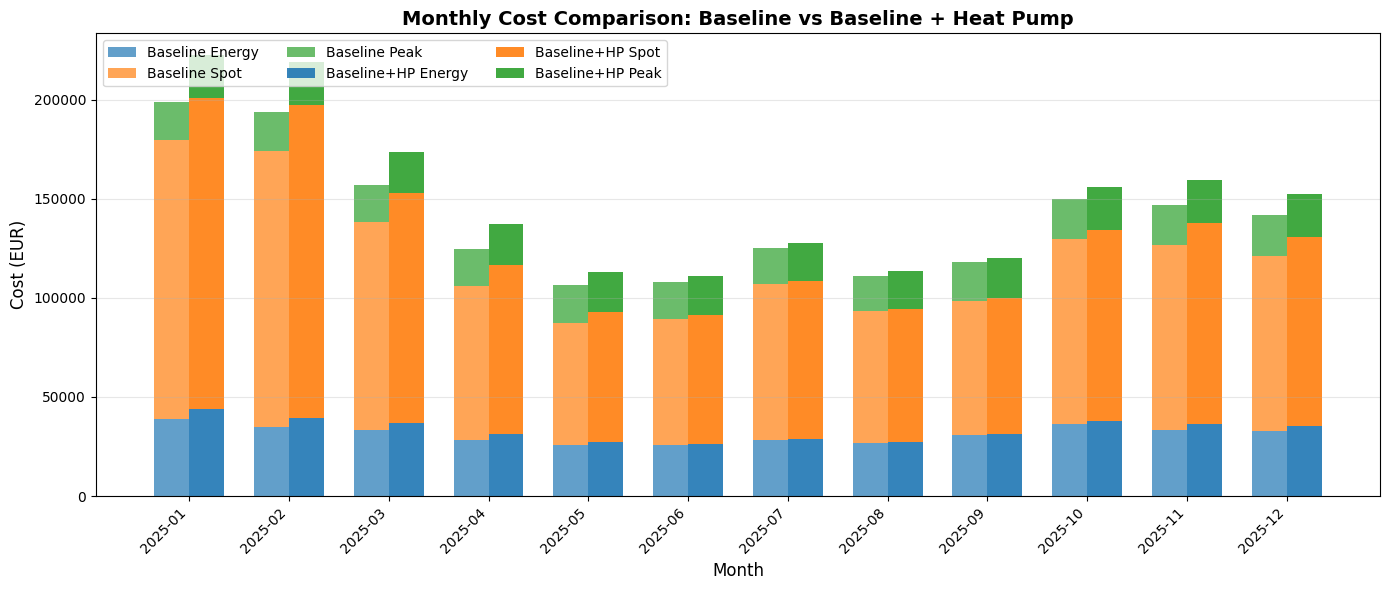

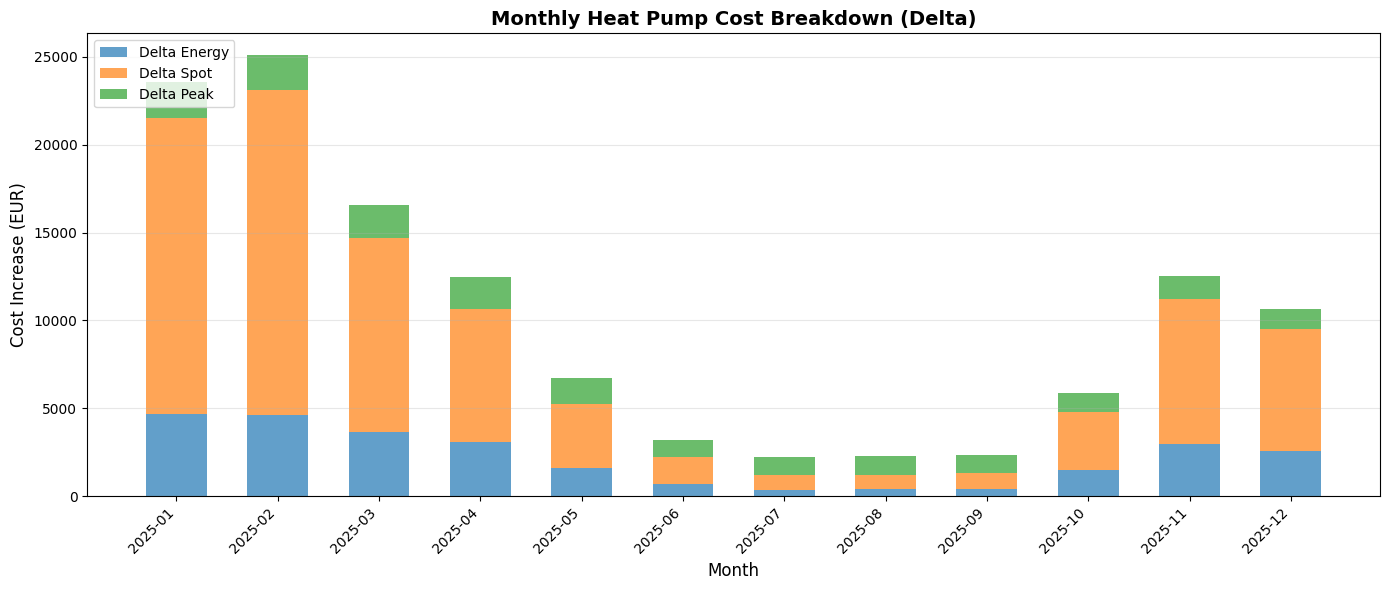

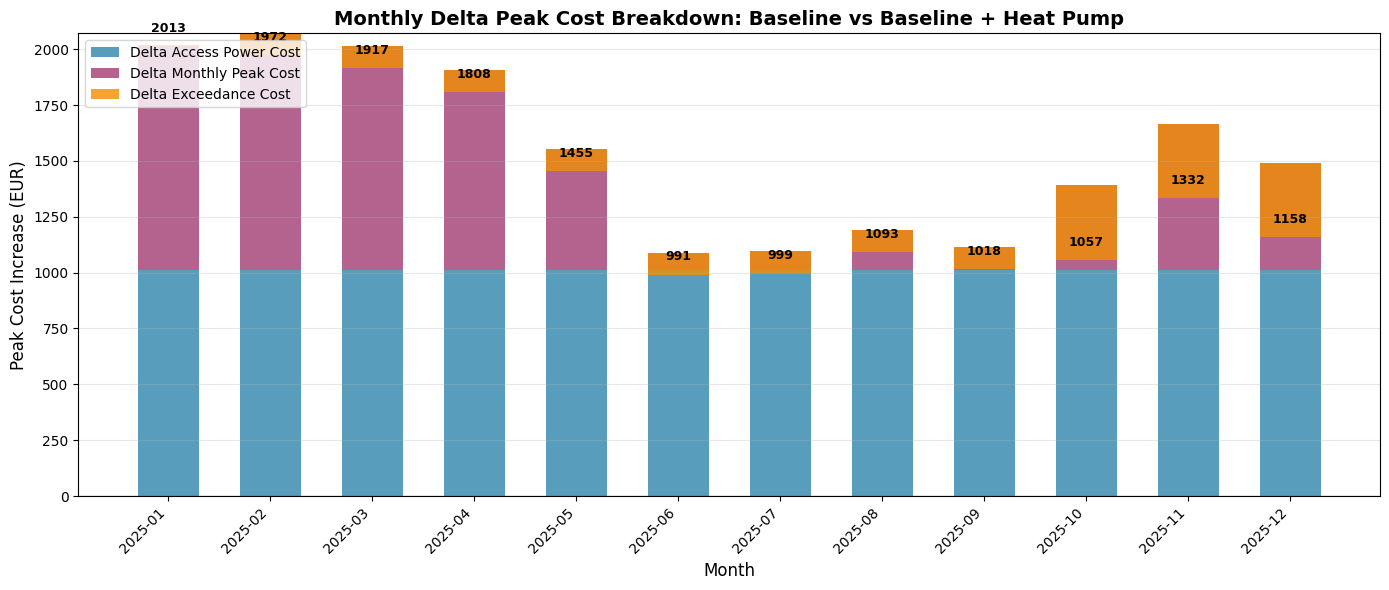

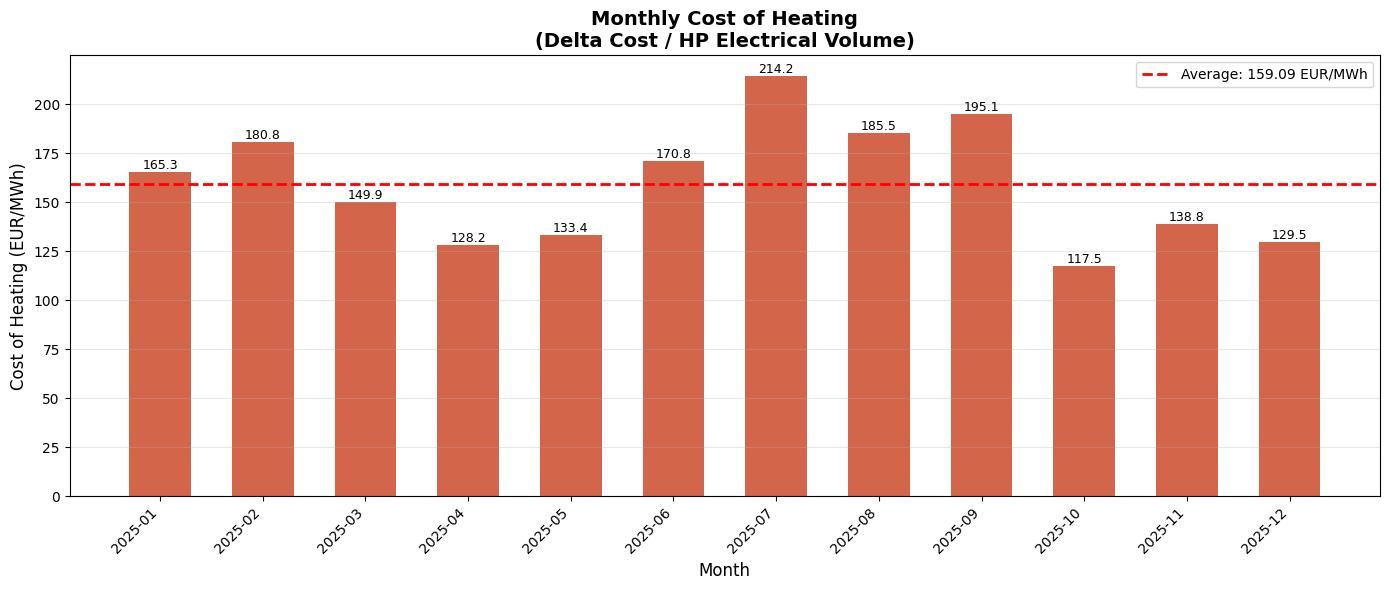

COST OF HEATING STATISTICS

Average cost of heating: 159.09 EUR/MWh
Median cost of heating: 157.62 EUR/MWh
Min cost of heating: 117.48 EUR/MWh
Max cost of heating: 214.24 EUR/MWh

Total HP electrical volume: 814.95 MWh
Total delta cost: 123464.10 EUR
Overall cost of heating: 151.50 EUR/MWh


In [6]:
# Calculate total volumes and peak powers for comparison
baseline_total_volume_mwh = baseline_bills['volume_mwh'].sum()
baseline_hp_total_volume_mwh = baseline_hp_bills['volume_mwh'].sum()
hp_load_total_mwh = hp_load_df['hp_electrical_load'].sum() / 1000

# Peak power values (maximum monthly peak across the year)
baseline_max_peak_kw = baseline_bills['monthly_peak_kw'].max()
baseline_hp_max_peak_kw = baseline_hp_bills['monthly_peak_kw'].max()
peak_increase_kw = baseline_hp_max_peak_kw - baseline_max_peak_kw

# Average monthly peak
baseline_avg_peak_kw = baseline_bills['monthly_peak_kw'].mean()
baseline_hp_avg_peak_kw = baseline_hp_bills['monthly_peak_kw'].mean()

# Access power values (baseline: monthly conservative AP — use max for one-line summary)
baseline_access_power_kw = baseline_bills["access_power_kw"].max()
baseline_hp_access_power_kw = baseline_hp_bills["access_power_kw"].max()  # max monthly heuristic AP

# Print peak power summary with actual billing values
print("="*80)
print("PEAK POWER AND ACCESS POWER COMPARISON")
print("="*80)
print(f"\nBaseline (no HP):")
print(f"  Access power (used in billing): {baseline_access_power_kw:.2f} kW (max monthly; conservative)")
print(f"  Maximum monthly peak: {baseline_max_peak_kw:.2f} kW")
print(f"  Average monthly peak: {baseline_avg_peak_kw:.2f} kW")
print(f"\nBaseline + HP:")
print(f"  Access power (used in billing): {baseline_hp_access_power_kw:.2f} kW (max monthly; conservative + HP @ -10°C)")
print(f"  Maximum monthly peak: {baseline_hp_max_peak_kw:.2f} kW")
print(f"  Average monthly peak: {baseline_hp_avg_peak_kw:.2f} kW")
print(f"\nPeak increase from HP: {peak_increase_kw:.2f} kW ({peak_increase_kw/baseline_max_peak_kw*100:.1f}%)")
print("="*80)

# Print monthly peak and access power table (actual values used in billing)
print("\n" + "="*80)
print("MONTHLY PEAK POWER AND ACCESS POWER (Values Used in Billing)")
print("="*80)
monthly_peak_access_table = pd.DataFrame({
    'Month': baseline_bills['month'],
    'Baseline Access Power (kW)': baseline_bills['access_power_kw'],
    'Baseline Monthly Peak (kW)': baseline_bills['monthly_peak_kw'],
    'Baseline Exceedance (kW)': baseline_bills['exceedance_kw'],
    'HP Access Power (kW)': baseline_hp_bills['access_power_kw'],
    'HP Monthly Peak (kW)': baseline_hp_bills['monthly_peak_kw'],
    'HP Exceedance (kW)': baseline_hp_bills['exceedance_kw'],
    'Peak Increase (kW)': baseline_hp_bills['monthly_peak_kw'] - baseline_bills['monthly_peak_kw'],
    'Exceedance Change (kW)': baseline_hp_bills['exceedance_kw'] - baseline_bills['exceedance_kw']
})
display(monthly_peak_access_table.style.format({
    'Baseline Access Power (kW)': '{:,.2f}',
    'Baseline Monthly Peak (kW)': '{:,.2f}',
    'Baseline Exceedance (kW)': '{:,.2f}',
    'HP Access Power (kW)': '{:,.2f}',
    'HP Monthly Peak (kW)': '{:,.2f}',
    'HP Exceedance (kW)': '{:,.2f}',
    'Peak Increase (kW)': '{:,.2f}',
    'Exceedance Change (kW)': '{:,.2f}'
}))
print("="*80)

# Create comparison table
comparison_data = {
    'Scenario': ['Baseline (no HP)', 'Baseline + HP', 'Delta (HP cost)'],
    'Total Load (MWh)': [
        baseline_total_volume_mwh,
        baseline_hp_total_volume_mwh,
        baseline_hp_total_volume_mwh - baseline_total_volume_mwh
    ],
    'HP Load (MWh)': [
        0.0,
        hp_load_total_mwh,
        hp_load_total_mwh
    ],
    'Access Power (kW)': [
        baseline_access_power_kw,
        baseline_hp_access_power_kw,
        baseline_hp_access_power_kw - baseline_access_power_kw
    ],
    'Max Monthly Peak (kW)': [
        baseline_max_peak_kw,
        baseline_hp_max_peak_kw,
        peak_increase_kw
    ],
    'Energy Cost (EUR)': [
        baseline_bills['energy_cost_eur'].sum(),
        baseline_hp_bills['energy_cost_eur'].sum(),
        baseline_hp_bills['energy_cost_eur'].sum() - baseline_bills['energy_cost_eur'].sum()
    ],
    'Spot Cost (EUR)': [
        baseline_bills['spot_cost_eur'].sum(),
        baseline_hp_bills['spot_cost_eur'].sum(),
        baseline_hp_bills['spot_cost_eur'].sum() - baseline_bills['spot_cost_eur'].sum()
    ],
    'Peak Cost (EUR)': [
        baseline_bills['peak_based_cost_eur'].sum(),
        baseline_hp_bills['peak_based_cost_eur'].sum(),
        baseline_hp_bills['peak_based_cost_eur'].sum() - baseline_bills['peak_based_cost_eur'].sum()
    ],
    'Injection Revenue (EUR)': [
        baseline_injection_revenue,
        baseline_hp_injection_revenue,
        baseline_hp_injection_revenue - baseline_injection_revenue
    ],
    'Net Total Cost (EUR)': [
        baseline_net_total,
        baseline_hp_net_total,
        baseline_hp_net_total - baseline_net_total
    ]
}

comparison_df = pd.DataFrame(comparison_data)

# Display formatted table
print("="*80)
print("COST COMPARISON: BASELINE vs BASELINE + HEAT PUMP")
print("="*80)
display(comparison_df.style.format({
    'Total Load (MWh)': '{:,.2f}',
    'HP Load (MWh)': '{:,.2f}',
    'Access Power (kW)': '{:,.2f}',
    'Max Monthly Peak (kW)': '{:,.2f}',
    'Energy Cost (EUR)': '{:,.2f}',
    'Spot Cost (EUR)': '{:,.2f}',
    'Peak Cost (EUR)': '{:,.2f}',
    'Injection Revenue (EUR)': '{:,.2f}',
    'Net Total Cost (EUR)': '{:,.2f}'
}))

# Monthly comparison
monthly_comparison = pd.DataFrame({
    'month': baseline_bills['month'],
    'baseline_volume_mwh': baseline_bills['volume_mwh'],
    'baseline_hp_volume_mwh': baseline_hp_bills['volume_mwh'],
    'baseline_access_power_kw': baseline_bills['access_power_kw'],
    'baseline_hp_access_power_kw': baseline_hp_bills['access_power_kw'],
    'baseline_peak_kw': baseline_bills['monthly_peak_kw'],
    'baseline_hp_peak_kw': baseline_hp_bills['monthly_peak_kw'],
    'baseline_energy': baseline_bills['energy_cost_eur'],
    'baseline_hp_energy': baseline_hp_bills['energy_cost_eur'],
    'baseline_spot': baseline_bills['spot_cost_eur'],
    'baseline_hp_spot': baseline_hp_bills['spot_cost_eur'],
    'baseline_peak': baseline_bills['peak_based_cost_eur'],
    'baseline_hp_peak': baseline_hp_bills['peak_based_cost_eur'],
    'baseline_total': baseline_bills['total_cost_eur'] - baseline_injection['injection_net_revenue_eur'],
    'baseline_hp_total': baseline_hp_bills['total_cost_eur'] - baseline_hp_injection['injection_net_revenue_eur']
})

monthly_comparison['delta_volume_mwh'] = monthly_comparison['baseline_hp_volume_mwh'] - monthly_comparison['baseline_volume_mwh']
monthly_comparison['delta_access_power_kw'] = monthly_comparison['baseline_hp_access_power_kw'] - monthly_comparison['baseline_access_power_kw']
monthly_comparison['delta_peak_kw'] = monthly_comparison['baseline_hp_peak_kw'] - monthly_comparison['baseline_peak_kw']
monthly_comparison['delta_total'] = monthly_comparison['baseline_hp_total'] - monthly_comparison['baseline_total']
monthly_comparison['delta_energy'] = monthly_comparison['baseline_hp_energy'] - monthly_comparison['baseline_energy']
monthly_comparison['delta_spot'] = monthly_comparison['baseline_hp_spot'] - monthly_comparison['baseline_spot']
monthly_comparison['delta_peak'] = monthly_comparison['baseline_hp_peak'] - monthly_comparison['baseline_peak']

# Add individual peak cost components for breakdown analysis
monthly_comparison['baseline_access_cost'] = baseline_bills['access_cost_eur'].values
monthly_comparison['baseline_monthly_peak_cost'] = baseline_bills['monthly_peak_cost_eur'].values
monthly_comparison['baseline_over_usage_cost'] = baseline_bills['over_usage_cost_eur'].values
monthly_comparison['baseline_hp_access_cost'] = baseline_hp_bills['access_cost_eur'].values
monthly_comparison['baseline_hp_monthly_peak_cost'] = baseline_hp_bills['monthly_peak_cost_eur'].values
monthly_comparison['baseline_hp_over_usage_cost'] = baseline_hp_bills['over_usage_cost_eur'].values

# Calculate deltas for each peak cost component
monthly_comparison['delta_access_cost'] = monthly_comparison['baseline_hp_access_cost'] - monthly_comparison['baseline_access_cost']
monthly_comparison['delta_monthly_peak_cost'] = monthly_comparison['baseline_hp_monthly_peak_cost'] - monthly_comparison['baseline_monthly_peak_cost']
monthly_comparison['delta_over_usage_cost'] = monthly_comparison['baseline_hp_over_usage_cost'] - monthly_comparison['baseline_over_usage_cost']

# Calculate monthly HP electrical volume for cost of heating calculation
# Merge HP load data with monthly comparison
hp_load_df['timestamp'] = pd.to_datetime(hp_load_df['timestamp'], utc=True)
hp_load_df['timestamp'] = hp_load_df['timestamp'].dt.tz_localize(None)
hp_load_df['month'] = pd.to_datetime(hp_load_df['timestamp']).dt.to_period('M')
monthly_hp_volume = hp_load_df.groupby('month')['hp_electrical_load'].sum() / 1000  # Convert to MWh
monthly_hp_volume_dict = {str(month): volume for month, volume in monthly_hp_volume.items()}
monthly_comparison['hp_volume_mwh'] = monthly_comparison['month'].astype(str).map(monthly_hp_volume_dict).fillna(0.0)

# Calculate cost of heating (EUR/MWh) = delta_total / hp_volume_mwh
monthly_comparison['cost_of_heating_eur_per_mwh'] = monthly_comparison['delta_total'] / monthly_comparison['hp_volume_mwh'].replace(0, np.nan)

# Add year total row
year_row = pd.DataFrame({
    'month': ['Year'],
    'baseline_volume_mwh': [monthly_comparison['baseline_volume_mwh'].sum()],
    'baseline_hp_volume_mwh': [monthly_comparison['baseline_hp_volume_mwh'].sum()],
    'baseline_access_power_kw': [monthly_comparison['baseline_access_power_kw'].max()],  # max monthly conservative
    'baseline_hp_access_power_kw': [monthly_comparison['baseline_hp_access_power_kw'].max()],  # max monthly heuristic
    'baseline_peak_kw': [monthly_comparison['baseline_peak_kw'].max()],  # Max peak across year
    'baseline_hp_peak_kw': [monthly_comparison['baseline_hp_peak_kw'].max()],  # Max peak across year
    'baseline_energy': [monthly_comparison['baseline_energy'].sum()],
    'baseline_hp_energy': [monthly_comparison['baseline_hp_energy'].sum()],
    'baseline_spot': [monthly_comparison['baseline_spot'].sum()],
    'baseline_hp_spot': [monthly_comparison['baseline_hp_spot'].sum()],
    'baseline_peak': [monthly_comparison['baseline_peak'].sum()],
    'baseline_hp_peak': [monthly_comparison['baseline_hp_peak'].sum()],
    'baseline_total': [monthly_comparison['baseline_total'].sum()],
    'baseline_hp_total': [monthly_comparison['baseline_hp_total'].sum()],
    'delta_volume_mwh': [monthly_comparison['delta_volume_mwh'].sum()],
    'delta_access_power_kw': [monthly_comparison['baseline_hp_access_power_kw'].max() - monthly_comparison['baseline_access_power_kw'].max()],
    'delta_peak_kw': [monthly_comparison['baseline_hp_peak_kw'].max() - monthly_comparison['baseline_peak_kw'].max()],
    'delta_total': [monthly_comparison['delta_total'].sum()],
    'delta_energy': [monthly_comparison['delta_energy'].sum()],
    'delta_spot': [monthly_comparison['delta_spot'].sum()],
    'delta_peak': [monthly_comparison['delta_peak'].sum()]
})

monthly_comparison_with_year = pd.concat([monthly_comparison, year_row], ignore_index=True)

print("\n" + "="*80)
print("MONTHLY COST COMPARISON")
print("="*80)
display(monthly_comparison_with_year.style.format({
    'baseline_volume_mwh': '{:,.2f}',
    'baseline_hp_volume_mwh': '{:,.2f}',
    'delta_volume_mwh': '{:,.2f}',
    'baseline_access_power_kw': '{:,.2f}',
    'baseline_hp_access_power_kw': '{:,.2f}',
    'delta_access_power_kw': '{:,.2f}',
    'baseline_peak_kw': '{:,.2f}',
    'baseline_hp_peak_kw': '{:,.2f}',
    'delta_peak_kw': '{:,.2f}',
    'baseline_energy': '{:,.2f}',
    'baseline_hp_energy': '{:,.2f}',
    'baseline_spot': '{:,.2f}',
    'baseline_hp_spot': '{:,.2f}',
    'baseline_peak': '{:,.2f}',
    'baseline_hp_peak': '{:,.2f}',
    'baseline_total': '{:,.2f}',
    'baseline_hp_total': '{:,.2f}',
    'delta_total': '{:,.2f}',
    'delta_energy': '{:,.2f}',
    'delta_spot': '{:,.2f}',
    'delta_peak': '{:,.2f}'
}))

# Visualization: Stacked bar chart comparing baseline vs baseline + HP
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(monthly_comparison))
width = 0.35

# Stacked bars for baseline
baseline_energy_bars = ax.bar(x - width/2, monthly_comparison['baseline_energy'], width, 
                               label='Baseline Energy', color='tab:blue', alpha=0.7)
baseline_spot_bars = ax.bar(x - width/2, monthly_comparison['baseline_spot'], width,
                            bottom=monthly_comparison['baseline_energy'],
                            label='Baseline Spot', color='tab:orange', alpha=0.7)
baseline_peak_bars = ax.bar(x - width/2, monthly_comparison['baseline_peak'], width,
                            bottom=monthly_comparison['baseline_energy'] + monthly_comparison['baseline_spot'],
                            label='Baseline Peak', color='tab:green', alpha=0.7)

# Stacked bars for baseline + HP
hp_energy_bars = ax.bar(x + width/2, monthly_comparison['baseline_hp_energy'], width,
                        label='Baseline+HP Energy', color='tab:blue', alpha=0.9)
hp_spot_bars = ax.bar(x + width/2, monthly_comparison['baseline_hp_spot'], width,
                     bottom=monthly_comparison['baseline_hp_energy'],
                     label='Baseline+HP Spot', color='tab:orange', alpha=0.9)
hp_peak_bars = ax.bar(x + width/2, monthly_comparison['baseline_hp_peak'], width,
                     bottom=monthly_comparison['baseline_hp_energy'] + monthly_comparison['baseline_hp_spot'],
                     label='Baseline+HP Peak', color='tab:green', alpha=0.9)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Cost (EUR)', fontsize=12)
ax.set_title('Monthly Cost Comparison: Baseline vs Baseline + Heat Pump', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(monthly_comparison['month'], rotation=45, ha='right')
ax.legend(loc='upper left', ncol=3)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Visualization: Delta (HP cost) per month
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(monthly_comparison))
width = 0.6

delta_energy_bars = ax.bar(x, monthly_comparison['delta_energy'], width,
                           label='Delta Energy', color='tab:blue', alpha=0.7)
delta_spot_bars = ax.bar(x, monthly_comparison['delta_spot'], width,
                         bottom=monthly_comparison['delta_energy'],
                         label='Delta Spot', color='tab:orange', alpha=0.7)
delta_peak_bars = ax.bar(x, monthly_comparison['delta_peak'], width,
                         bottom=monthly_comparison['delta_energy'] + monthly_comparison['delta_spot'],
                         label='Delta Peak', color='tab:green', alpha=0.7)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Cost Increase (EUR)', fontsize=12)
ax.set_title('Monthly Heat Pump Cost Breakdown (Delta)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(monthly_comparison['month'], rotation=45, ha='right')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Visualization: Delta Peak Cost Breakdown per Month
# Split delta peak cost into: delta access power cost, delta exceedance cost, delta monthly peak cost
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(monthly_comparison))
width = 0.6

# Stacked bars showing breakdown of delta peak cost
delta_access_bars = ax.bar(x, monthly_comparison['delta_access_cost'], width,
                           label='Delta Access Power Cost', color='#2E86AB', alpha=0.8)
delta_monthly_peak_bars = ax.bar(x, monthly_comparison['delta_monthly_peak_cost'], width,
                                  bottom=monthly_comparison['delta_access_cost'],
                                  label='Delta Monthly Peak Cost', color='#A23B72', alpha=0.8)
delta_exceedance_bars = ax.bar(x, monthly_comparison['delta_over_usage_cost'], width,
                                bottom=monthly_comparison['delta_access_cost'] + monthly_comparison['delta_monthly_peak_cost'],
                                label='Delta Exceedance Cost', color='#F18F01', alpha=0.8)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Peak Cost Increase (EUR)', fontsize=12)
ax.set_title('Monthly Delta Peak Cost Breakdown: Baseline vs Baseline + Heat Pump', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(monthly_comparison['month'], rotation=45, ha='right')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

# Add value labels on bars if they're significant
for i in range(len(monthly_comparison)):
    total_delta = monthly_comparison['delta_peak'].iloc[i]
    if abs(total_delta) > 100:  # Only label if significant
        ax.text(i, total_delta + (50 if total_delta > 0 else -50), 
                f'{total_delta:.0f}', ha='center', va='bottom' if total_delta > 0 else 'top', 
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Visualization: Cost of Heating (Delta Cost / HP Electrical Volume)
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(monthly_comparison))
width = 0.6

# Filter out months with zero HP volume
valid_months = monthly_comparison['hp_volume_mwh'] > 0
cost_of_heating = monthly_comparison.loc[valid_months, 'cost_of_heating_eur_per_mwh']
valid_month_labels = monthly_comparison.loc[valid_months, 'month']
x_valid = np.arange(len(cost_of_heating))

bars = ax.bar(x_valid, cost_of_heating, width, color='#C73E1D', alpha=0.8)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Cost of Heating (EUR/MWh)', fontsize=12)
ax.set_title('Monthly Cost of Heating\n(Delta Cost / HP Electrical Volume)', fontsize=14, fontweight='bold')
ax.set_xticks(x_valid)
ax.set_xticklabels(valid_month_labels, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=cost_of_heating.mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Average: {cost_of_heating.mean():.2f} EUR/MWh')
ax.legend()

# Add value labels on bars
for bar, val in zip(bars, cost_of_heating):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Print summary statistics for cost of heating
print("="*80)
print("COST OF HEATING STATISTICS")
print("="*80)
print(f"\nAverage cost of heating: {cost_of_heating.mean():.2f} EUR/MWh")
print(f"Median cost of heating: {cost_of_heating.median():.2f} EUR/MWh")
print(f"Min cost of heating: {cost_of_heating.min():.2f} EUR/MWh")
print(f"Max cost of heating: {cost_of_heating.max():.2f} EUR/MWh")
print(f"\nTotal HP electrical volume: {monthly_comparison['hp_volume_mwh'].sum():.2f} MWh")
print(f"Total delta cost: {monthly_comparison['delta_total'].sum():.2f} EUR")
print(f"Overall cost of heating: {monthly_comparison['delta_total'].sum() / monthly_comparison['hp_volume_mwh'].sum():.2f} EUR/MWh")
print("="*80)

## Run Optimization

This section runs the **deterministic MPC optimization** to find the optimal heat pump operation schedule that minimizes total costs while meeting thermal load requirements.

**What the optimization does:**
- **Optimization model setup:**
  - Creates a mathematical optimization model with constraints
  - Defines objective function to minimize total costs
  - Sets up constraints for:
    - Heat pump power limits (maximum electrical and thermal capacity)
    - Buffer SOC limits (minimum and maximum state of charge)
    - Buffer state updates (thermal energy balance)
    - Thermal load satisfaction (must meet demand)
    - Power balance (grid consumption = inflexible load + EV baseline + HP electrical input - PV production)
    - Monthly peak power tracking
    - Access power rules

- **Optimization process:**
  - Solves the optimization problem for all 35,040 time periods (one year)
  - Determines optimal HP operation schedule considering:
    - Electricity prices (operate when prices are low)
    - PV production availability (prefer operating during solar generation)
    - Peak power reduction (avoid simultaneous high loads)
    - Thermal load requirements (ensure all heating demand is met)
    - Buffer flexibility (store thermal energy when prices are low, use when prices are high)

**What you'll see:**
- Progress indicators showing optimization steps
- Model statistics (number of variables, constraints, time periods)
- Optimization results including:
  - Optimized HP electrical input schedule
  - Optimized HP thermal output
  - Buffer SOC profile
  - Optimized grid consumption
  - Optimized monthly peak powers
  - Optimized access power

The optimization typically takes several minutes to solve for a full year of data.

### Optimization Model: Objective Function and Constraints

The optimization model (from `src/optimization.py`) minimizes total cost while meeting all operational constraints:

#### Objective Function
Minimize: **Total Cost = Energy Cost + Spot Cost + Peak-Based Costs - Injection Revenue**

**Energy Cost:**
- Formula: `Σ(grid_consumption[t] × (energy_rate_eur_per_mwh/1000 + grid_losses_percentage × spot_price[t]))`
- Energy rate: ~30.4 €/MWh (fixed costs from config)
- Grid losses: 1.75% of spot price per interval

**Spot Cost:**
- Formula: `Σ(grid_consumption[t] × spot_price_eur_per_kwh[t])`
- Spot price converted from €/MWh to €/kWh

**Peak-Based Costs:**
- Access power cost: `Σ(access_power[m] × 2.9975458)` per month
- Monthly peak cost: `Σ(monthly_peak[m] × 4.2269465)` per month
- Over-usage cost: `Σ(rolling_max_exceedance[m] × 4.4963187)` per month

**Injection Revenue** (negative cost):
- Formula: `-Σ(grid_injection[t] × net_injection_price_eur_per_kwh[t])`
- Net injection price = spot_price - imbalance_cost (21.148 €/MWh)

#### Constraints

**Heat Pump Constraints:**
1. **Thermal Output**: `hp_thermal_output[t] = hp_electrical_input[t] × COP[t]` (COP varies with outdoor temperature)
2. **Thermal Power Limit**: `hp_thermal_output[t] ≤ thermal_max_kw × 0.25` (kW, 15-min period)
3. **Electrical Input Limit**: `hp_electrical_input[t] ≤ thermal_max_kw / COP_min × 0.25` (kW, 15-min period)
4. **Modulating Operation**: `hp_electrical_input[t] ∈ [0, max_electrical_input]` (continuous variable, not binary)

**Buffer (Thermal Storage) Constraints:**
1. **Buffer Capacity**: `buffer_energy_capacity = buffer_size_m3 × water_density × cp × usable_delta_t / 3600` (kWh)
2. **SOC Limits**: `SOC_min ≤ SOC[t] ≤ SOC_max` (typically 0.20 - 0.95)
3. **Buffer State Update**: `SOC[t+1] = SOC[t] - thermal_load[t]/capacity + hp_thermal_output[t]/capacity - losses[t]`
4. **Thermal Load Satisfaction**: Buffer SOC bounds ensure thermal load is always met (SOC cannot drop below minimum when load is high)

**Power Balance:**
- `grid_consumption[t] - grid_injection[t] = inflex_load[t] + ev_baseline[t] + hp_electrical_input[t] - pv_production[t]`
- Net grid power = Total load - PV production

**Grid Power:**
- `grid_power[t] = (grid_consumption[t] - grid_injection[t]) × 4` (kW, positive = consumption)

**Peak Tracking:**
- `monthly_peak[m] ≥ grid_consumption[t] × 4` for all periods t in month m
- Peak is based on grid consumption (offtake), not net power

**Exceedance:**
- `exceedance[t] ≥ monthly_peak[m] - access_power[m]` for all periods t in month m
- Rolling max exceedance: `rolling_max_exceedance[m] ≥ exceedance[k]` for k in [m-11, m]

**Access Power Rules:**
- Access power can be increased at any time (monthly)
- Access power can only be reduced 12 months after an increase (lock-in period)
- Binary variables track increases and enforce lock-in constraints

#### Key Parameters (from `config/hp.yaml` and `config/billing.yaml`)
- **Heat Pump**: Thermal max capacity 1000 kW, COP varies from 2.22-3.12 based on outdoor temperature
- **Buffer**: Size 200 m³ (default), SOC limits 0.20-0.95, initial SOC 0.50
- **Energy costs**: Fixed rate ~30.4 €/MWh, grid losses 1.75%
- **Peak costs**: Access power 2.9975 €/kW/month, Monthly peak 4.227 €/kW/month, Over-usage 4.496 €/kW/month
- **Injection**: Imbalance cost 21.148 €/MWh 
- **Access power**:  (optimized variable)

In [7]:
# Run deterministic MPC optimization for heat pump
# This will optimize:
# 1. HP electrical input schedule (when to operate the heat pump)
# 2. Buffer SOC profile (thermal energy storage)
# 3. Access power capacity (optimal contracted capacity per month)
# 4. Grid consumption/injection to minimize total costs

config_path = "../config/billing.yaml"
hp_config_path = "../config/hp.yaml"

# Reload modules to pick up any changes
import importlib
import heat_pump_load
import optimization
importlib.reload(heat_pump_load)
importlib.reload(optimization)
# Re-import to get updated function after reload
from optimization import deterministic_mpc_hp

results_df, summary = deterministic_mpc_hp(
    df=df,
    config_path=config_path,
    hp_config_path=hp_config_path,
    timestamp_col="timestamp",
    pv_col="pv_production",
    inflex_load_col="inflex_load",
    price_col="price",
    ev_col="ev",
    thermal_load_col="thermal_load",
    outdoor_temp_col="outdoor_temperature"
)

# Reconstruct bills for optimized schedule using billing.py
# IMPORTANT: Use optimized access_power from results_df, not from config
import importlib
import billing
importlib.reload(billing)
from billing import calculate_monthly_bills, calculate_monthly_injection_bills

optimized_bills = calculate_monthly_bills(
    results_df.rename(columns={"spot_price": "price"}), 
    config,
    access_power_col="access_power"  # Use optimized access power from optimizer
)
optimized_injection = calculate_monthly_injection_bills(results_df.rename(columns={"spot_price": "price"}), config)
optimized_injection_revenue = optimized_injection['injection_net_revenue_eur'].sum()
optimized_net_total = optimized_bills['total_cost_eur'].sum() - optimized_injection_revenue

Deterministic MPC Optimization for Heat Pump System

[1/10] Loading billing configuration from: ../config/billing.yaml
   ✓ Billing configuration loaded

[2/10] Loading HP configuration from: ../config/hp.yaml
   ✓ HP configuration loaded
     - Thermal max capacity: 1000 kW
     - Buffer size: 80 m³
     - Buffer capacity: 928.89 kWh (calculated)
     - SOC limits: 0.20 - 0.95
     - Initial SOC: 0.50

[3/10] Preparing input data...
   Input DataFrame shape: (35040, 11)
   Columns: ['timestamp', 'grid_consumption', 'price', 'pv_production', 'grid_injection', 'total_consumption', 'ev', 'inflex_load', 'grid_consumption_excl_ev', 'thermal_load', 'outdoor_temperature']
   ✓ Filtered to 35040 periods (15-min intervals)
   Date range: 2025-01-01 00:00:00 to 2025-12-31 23:45:00

[4/10] Extracting input parameters...
   PV production: 1817081.40 kWh total
   Inflexible load: 13054151.51 kWh total
   EV baseline (uncontrollable): 345380.64 kWh total
   Thermal load: 2011352.00 kWh total
   Spo

## Compare Optimized vs Baseline HP

This section provides a comprehensive comparison between the optimized HP operation and baseline uncontrolled HP operation.

**What you'll see:**

### Cost Comparison
- **Annual cost breakdown** comparing:
  - Baseline + uncontrolled HP total costs
  - Optimized HP total costs
  - Total savings achieved
  - Savings percentage
  - Cost per MWh of HP electrical consumption

### Monthly Peak Power Comparison
- **Side-by-side bar charts** showing:
  - Monthly peak power for baseline + uncontrolled HP vs optimized HP
  - Peak power reduction achieved each month
  - Access power comparison (if optimized)

### Summary Statistics Table
- Detailed monthly comparison table with:
  - Peak power values
  - Access power values
  - Volume consumption
  - Reductions achieved

**Key insights:**
- The optimization typically achieves significant cost savings through intelligent load shifting
- Peak power reductions help lower capacity charges
- Load shifting to low-price periods reduces energy costs
- Better utilization of PV production reduces grid consumption
- Buffer flexibility enables cost-effective thermal energy storage

COST COMPARISON: BASELINE + UNCONTROLLED HP vs OPTIMIZED HP

Cost Component                    Baseline+HP (EUR)   Optimized HP (EUR)        Savings (EUR)
------------------------------------------------------------------------------------------
Energy Cost                              401,920.93           401,718.80               202.13
Spot Cost                              1,155,476.24         1,144,015.99            11,460.25
Access Power Cost                        111,194.93            98,797.61            12,397.32
Monthly Peak Cost                        136,623.23           130,160.36             6,462.86
Over-usage Cost                                0.00                 0.00                 0.00
Injection Revenue                             -0.01                -0.00                -0.01
------------------------------------------------------------------------------------------
TOTAL COST                             1,805,215.32         1,774,692.77            30,522.55

Tota

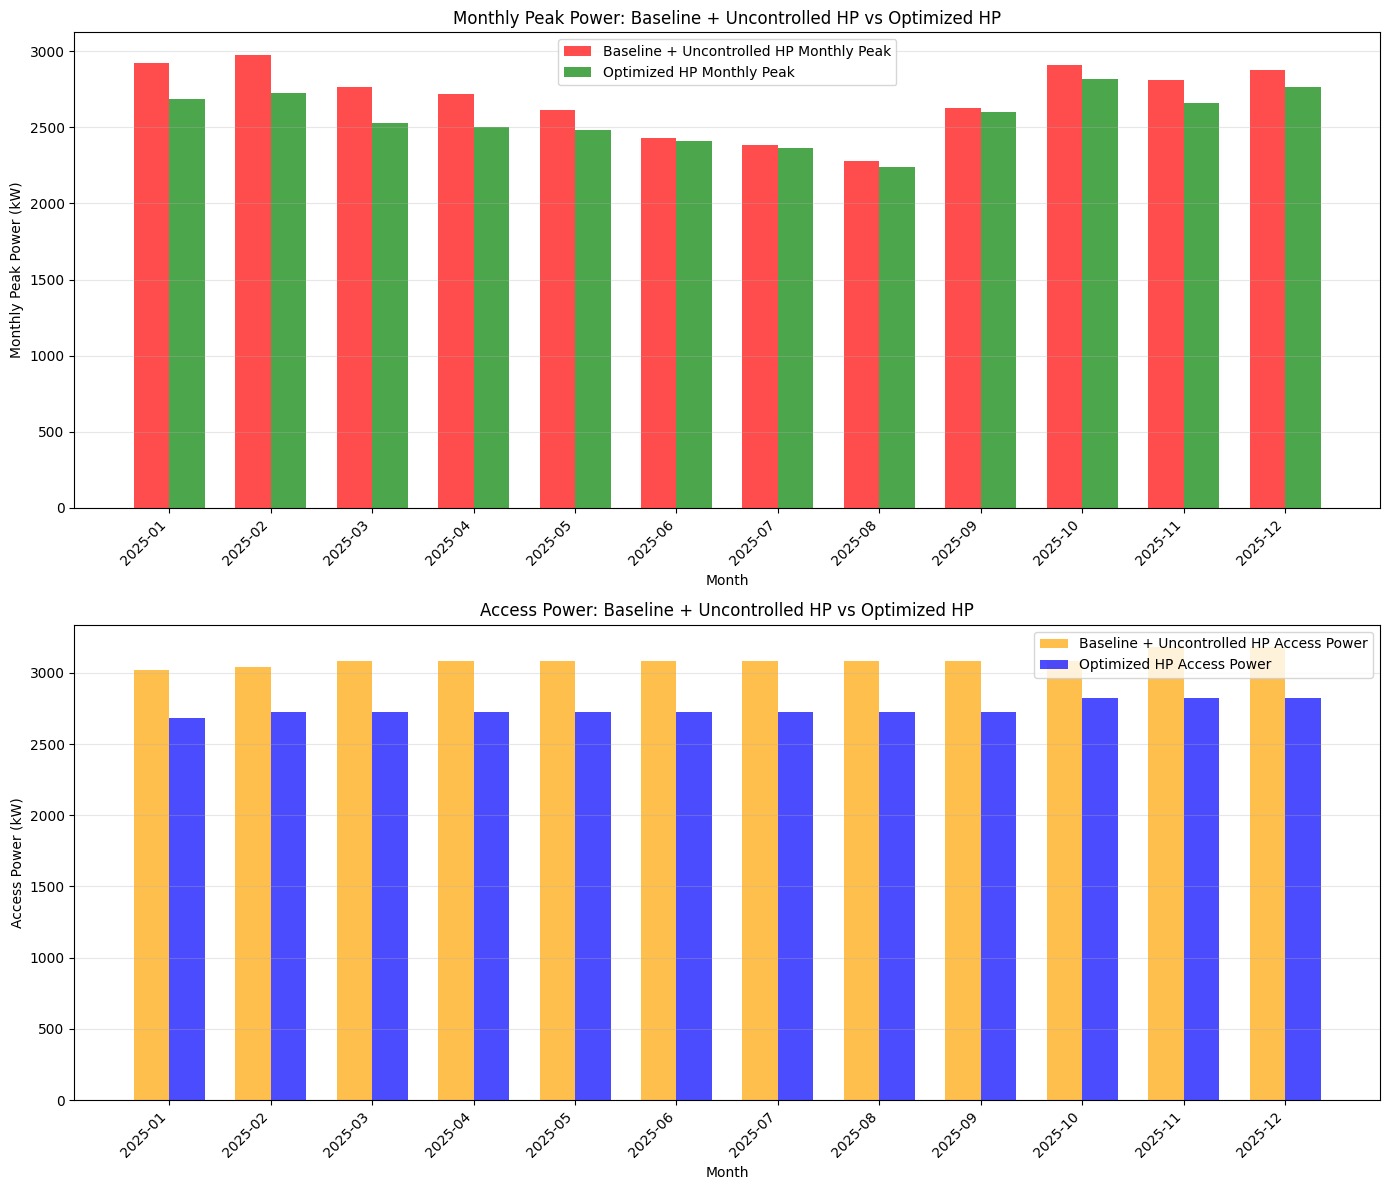


MONTHLY PEAK AND ACCESS POWER SUMMARY
  month  baseline_hp_peak_kw  optimized_peak_kw  baseline_hp_access_kw  optimized_access_kw  baseline_hp_volume_mwh  optimized_volume_mwh  peak_reduction_kw  access_reduction_kw  volume_reduction_mwh
2025-01          2922.205739             2684.5            3021.277028               2684.5             1333.001129           1332.445966         237.705739           336.777028              0.555162
2025-02          2976.852466             2726.5            3042.277028               2726.5             1187.186326           1187.172415         250.352466           315.777028              0.013910
2025-03          2764.353552             2527.0            3084.277028               2726.5             1133.047535           1130.452508         237.353552           357.777028              2.595027
2025-04          2717.596493             2506.0            3084.277028               2726.5              976.904668            979.487031         211.596493     

In [8]:
# Compare costs: Baseline + uncontrolled HP vs Optimized HP
baseline_hp_total = baseline_hp_net_total  # Already calculated above
optimized_total = optimized_net_total

print("="*80)
print("COST COMPARISON: BASELINE + UNCONTROLLED HP vs OPTIMIZED HP")
print("="*80)
print(f"\n{'Cost Component':<30} {'Baseline+HP (EUR)':>20} {'Optimized HP (EUR)':>20} {'Savings (EUR)':>20}")
print("-"*90)

components = [
    ("Energy Cost", baseline_hp_bills['energy_cost_eur'].sum(), optimized_bills['energy_cost_eur'].sum()),
    ("Spot Cost", baseline_hp_bills['spot_cost_eur'].sum(), optimized_bills['spot_cost_eur'].sum()),
    ("Access Power Cost", baseline_hp_bills['access_cost_eur'].sum(), optimized_bills['access_cost_eur'].sum()),
    ("Monthly Peak Cost", baseline_hp_bills['monthly_peak_cost_eur'].sum(), optimized_bills['monthly_peak_cost_eur'].sum()),
    ("Over-usage Cost", baseline_hp_bills['over_usage_cost_eur'].sum(), optimized_bills['over_usage_cost_eur'].sum()),
    ("Injection Revenue", -baseline_hp_injection_revenue, -optimized_injection_revenue),
]

for name, baseline_val, optimized_val in components:
    savings = baseline_val - optimized_val
    print(f"{name:<30} {baseline_val:>20,.2f} {optimized_val:>20,.2f} {savings:>20,.2f}")

print("-"*90)
print(f"{'TOTAL COST':<30} {baseline_hp_total:>20,.2f} {optimized_total:>20,.2f} {baseline_hp_total - optimized_total:>20,.2f}")
print("="*80)

savings_pct = ((baseline_hp_total - optimized_total) / baseline_hp_total) * 100
print(f"\nTotal Savings: {baseline_hp_total - optimized_total:,.2f} EUR ({savings_pct:.2f}%)")

# Calculate HP electrical volume for cost per MWh calculation
hp_volume_kwh = results_df['hp_electrical_input'].sum()
hp_volume_mwh = hp_volume_kwh / 1000.0
baseline_hp_volume_mwh = baseline_hp_bills['volume_mwh'].sum() - baseline_bills['volume_mwh'].sum()

print(f"\nHP Electrical Volume:")
print(f"  Baseline + uncontrolled HP: {baseline_hp_volume_mwh:.2f} MWh")
print(f"  Optimized HP: {hp_volume_mwh:.2f} MWh")


# Plot monthly peak and access power comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1: Monthly Peak Power
ax1 = axes[0]
x = range(len(baseline_hp_bills))
width = 0.35
ax1.bar([i - width/2 for i in x], baseline_hp_bills['monthly_peak_kw'], width, 
        label='Baseline + Uncontrolled HP Monthly Peak', color='red', alpha=0.7)
ax1.bar([i + width/2 for i in x], optimized_bills['monthly_peak_kw'], width, 
        label='Optimized HP Monthly Peak', color='green', alpha=0.7)
ax1.set_xlabel('Month')
ax1.set_ylabel('Monthly Peak Power (kW)')
ax1.set_title('Monthly Peak Power: Baseline + Uncontrolled HP vs Optimized HP')
ax1.set_xticks(x)
ax1.set_xticklabels(baseline_hp_bills['month'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Access Power
ax2 = axes[1]
ax2.bar([i - width/2 for i in x], baseline_hp_bills['access_power_kw'], width, 
        label='Baseline + Uncontrolled HP Access Power', color='orange', alpha=0.7)
ax2.bar([i + width/2 for i in x], optimized_bills['access_power_kw'], width, 
        label='Optimized HP Access Power', color='blue', alpha=0.7)
ax2.set_xlabel('Month')
ax2.set_ylabel('Access Power (kW)')
ax2.set_title('Access Power: Baseline + Uncontrolled HP vs Optimized HP')
ax2.set_xticks(x)
ax2.set_xticklabels(baseline_hp_bills['month'], rotation=45, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("MONTHLY PEAK AND ACCESS POWER SUMMARY")
print("="*80)
comparison_df = pd.DataFrame({
    'month': baseline_hp_bills['month'],
    'baseline_hp_peak_kw': baseline_hp_bills['monthly_peak_kw'],
    'optimized_peak_kw': optimized_bills['monthly_peak_kw'],
    'baseline_hp_access_kw': baseline_hp_bills['access_power_kw'],
    'optimized_access_kw': optimized_bills['access_power_kw'],
    'baseline_hp_volume_mwh': baseline_hp_bills['volume_mwh'],
    'optimized_volume_mwh': optimized_bills['volume_mwh'],
})
comparison_df['peak_reduction_kw'] = comparison_df['baseline_hp_peak_kw'] - comparison_df['optimized_peak_kw']
comparison_df['access_reduction_kw'] = comparison_df['baseline_hp_access_kw'] - comparison_df['optimized_access_kw']
comparison_df['volume_reduction_mwh'] = comparison_df['baseline_hp_volume_mwh'] - comparison_df['optimized_volume_mwh']
print(comparison_df.to_string(index=False))
print("="*80)

## Visualizations: Optimized HP Operation

This section provides detailed visualizations of the optimized heat pump operation schedule, showing how the MPC controller schedules HP operation to minimize costs.

**What you'll see:**

### Monthly Peak Power and Access Power Comparison
- **Monthly peak power comparison**: Bar charts showing baseline + uncontrolled HP vs optimized HP peak power for each month
- **Access power comparison**: Comparison of access power capacity between scenarios
- **Peak reduction**: Visual representation of peak power reductions achieved through optimization

### Weekly and Daily HP Operation Plots
- **Weekly view**: Select any week (1-52) to visualize:
  - HP electrical power (kW) - when the heat pump consumes electricity
  - HP thermal power (kW) - thermal output delivered
  - Buffer SOC (%) - state of charge of the thermal buffer
  - Spot price (EUR/MWh) - electricity prices overlaid on the same plot
  
- **Daily view**: Select any day of the week to see detailed 24-hour operation:
  - Same metrics as weekly view but zoomed to a single day
  - Shows detailed load shifting behavior
  - Illustrates how the buffer is charged during low-price periods and discharged during high-price periods

**Key insights from visualizations:**
- **Load shifting**: HP operation is shifted to low-price periods (often nighttime or periods with high PV production)
- **Buffer utilization**: Buffer SOC fluctuates to store thermal energy when prices are low and use it when prices are high
- **Peak reduction**: Optimized operation reduces peak power demand compared to uncontrolled operation
- **Price-responsive operation**: HP operation closely follows electricity price patterns

**How to use:**
- Change `week_number` (1-52) to visualize different weeks throughout the year
- Change `day_of_week` (0-6, where 0=Monday) to visualize different days
- Week 50 (mid-December) is recommended as it shows heavy heating load during winter

Visualizing week 50: 2025-12-10 to 2025-12-17


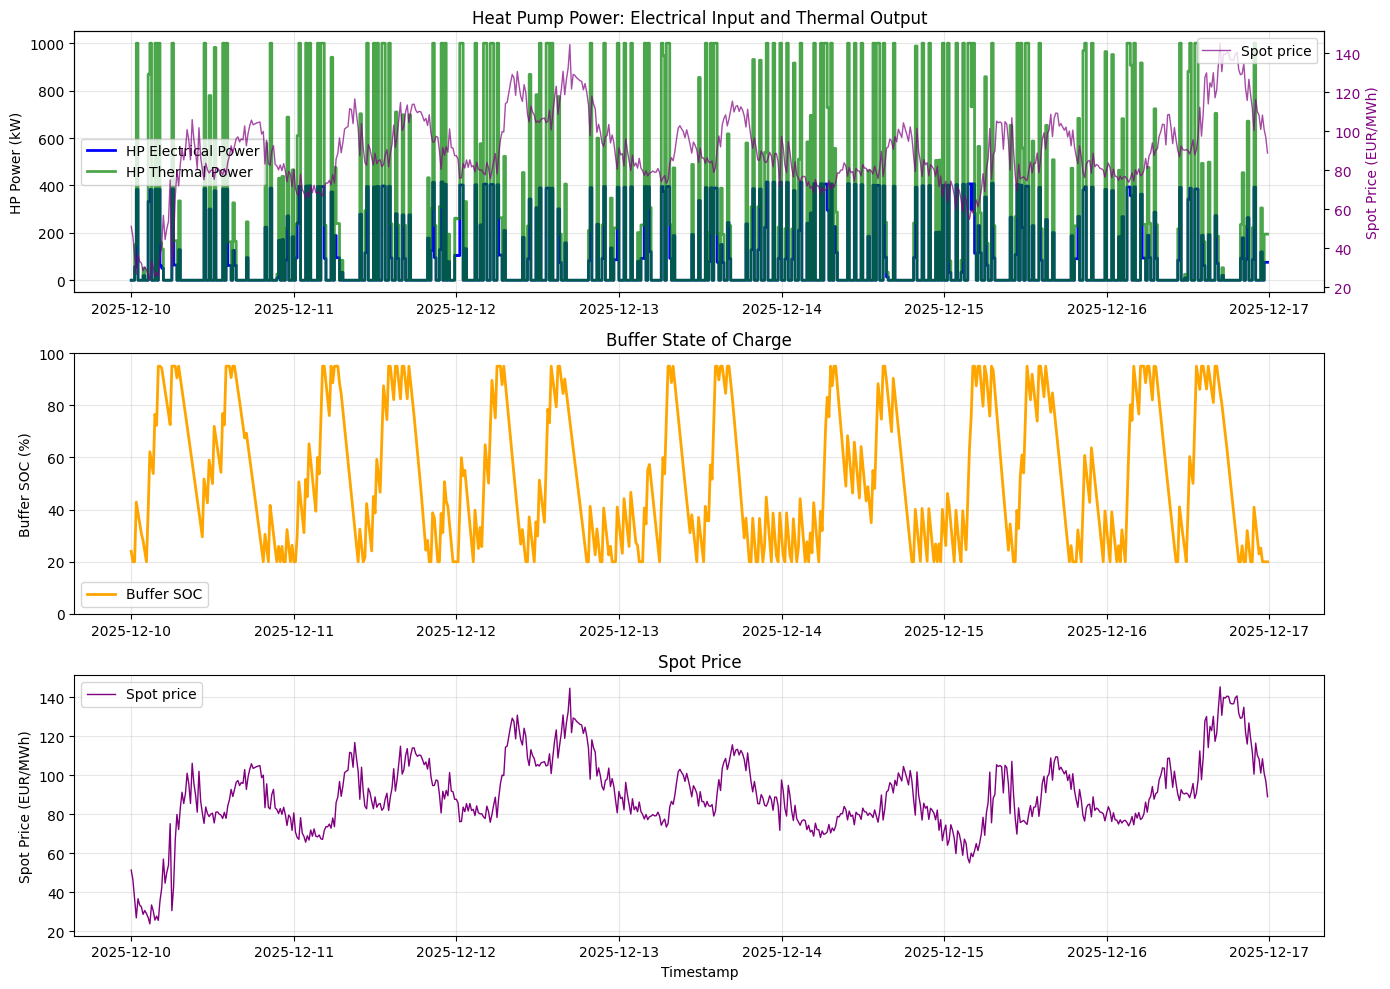


Visualizing day 1 of week 50: 2025-12-10


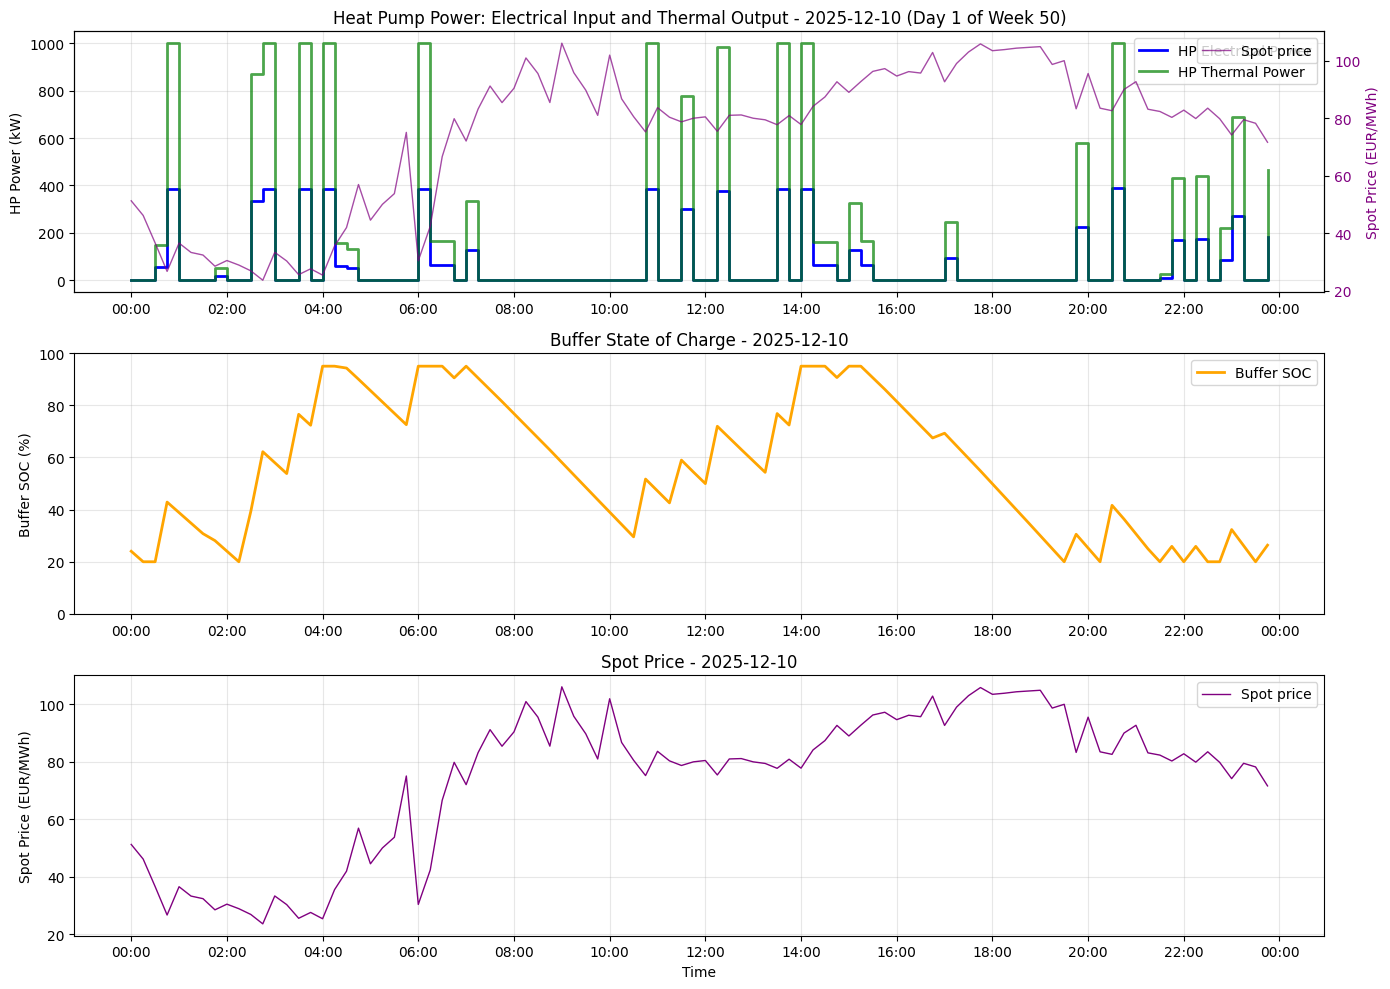

In [9]:
# Plot comparison: HP power, SOC, and price over one week
results_df['timestamp'] = pd.to_datetime(results_df['timestamp'])

# Select week to visualize (1-52, where 1 is first week of 2025)
# Week 50 corresponds to 15/12/2025-22/12/2025 (heavy loaded period)
week_number = 50  # Change this to select a different week (1-52)

# Calculate start and end dates based on week number
year = 2025
year_start = pd.Timestamp(f'{year}-01-01 00:00:00')
week_start_day = (week_number - 1) * 7
start_week = year_start + pd.Timedelta(days=week_start_day)
end_week = start_week + pd.Timedelta(days=7)

print(f"Visualizing week {week_number}: {start_week.strftime('%Y-%m-%d')} to {end_week.strftime('%Y-%m-%d')}")

week_data = results_df[(results_df['timestamp'] >= start_week) & (results_df['timestamp'] < end_week)]

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: HP thermal power
ax1 = axes[0]
# Convert hp_electrical_input from kWh to kW (multiply by 4)
hp_electrical_power_kw = week_data['hp_electrical_input'] * 4
ax1.step(week_data['timestamp'], hp_electrical_power_kw, label='HP Electrical Power', color='blue', linewidth=2, where='post')
ax1.step(week_data['timestamp'], week_data['hp_thermal_power'], label='HP Thermal Power', color='green', linewidth=2, alpha=0.7, where='post')
ax1.set_ylabel('HP Power (kW)')
ax1.set_title('Heat Pump Power: Electrical Input and Thermal Output')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add price curve on secondary y-axis
ax1_price = ax1.twinx()
ax1_price.plot(week_data['timestamp'], week_data['spot_price'], label='Spot price', color='purple', linewidth=1, alpha=0.7)
ax1_price.set_ylabel('Spot Price (EUR/MWh)', color='purple')
ax1_price.tick_params(axis='y', labelcolor='purple')
ax1_price.legend(loc='upper right')

# Plot 2: Buffer SOC
ax2 = axes[1]
ax2.plot(week_data['timestamp'], week_data['buffer_soc'] * 100, label='Buffer SOC', color='orange', linewidth=2)
ax2.set_ylabel('Buffer SOC (%)')
ax2.set_title('Buffer State of Charge')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 100])

# Plot 3: Spot price
ax3 = axes[2]
ax3.plot(week_data['timestamp'], week_data['spot_price'], label='Spot price', color='purple', linewidth=1)
ax3.set_ylabel('Spot Price (EUR/MWh)')
ax3.set_xlabel('Timestamp')
ax3.set_title('Spot Price')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Daily plot: Select a specific day from the selected week
day_of_week = 1  # Change this to select a day (1-7, where 1 is the first day of the selected week)

# Calculate the specific day to plot
selected_day_start = start_week + pd.Timedelta(days=day_of_week - 1)
selected_day_end = selected_day_start + pd.Timedelta(days=1)

print(f"\nVisualizing day {day_of_week} of week {week_number}: {selected_day_start.strftime('%Y-%m-%d')}")

# Filter data for the selected day
day_data = results_df[(results_df['timestamp'] >= selected_day_start) & (results_df['timestamp'] < selected_day_end)]

# Create daily plot
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: HP thermal power
ax1 = axes[0]
hp_electrical_power_kw_day = day_data['hp_electrical_input'] * 4
ax1.step(day_data['timestamp'], hp_electrical_power_kw_day, label='HP Electrical Power', color='blue', linewidth=2, where='post')
ax1.step(day_data['timestamp'], day_data['hp_thermal_power'], label='HP Thermal Power', color='green', linewidth=2, alpha=0.7, where='post')
ax1.set_ylabel('HP Power (kW)')
ax1.set_title(f'Heat Pump Power: Electrical Input and Thermal Output - {selected_day_start.strftime("%Y-%m-%d")} (Day {day_of_week} of Week {week_number})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add price curve on secondary y-axis
ax1_price = ax1.twinx()
ax1_price.plot(day_data['timestamp'], day_data['spot_price'], label='Spot price', color='purple', linewidth=1, alpha=0.7)
ax1_price.set_ylabel('Spot Price (EUR/MWh)', color='purple')
ax1_price.tick_params(axis='y', labelcolor='purple')
ax1_price.legend(loc='upper right')

# Format x-axis to show time
import matplotlib.dates as mdates
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=2))

# Plot 2: Buffer SOC
ax2 = axes[1]
ax2.plot(day_data['timestamp'], day_data['buffer_soc'] * 100, label='Buffer SOC', color='orange', linewidth=2)
ax2.set_ylabel('Buffer SOC (%)')
ax2.set_title(f'Buffer State of Charge - {selected_day_start.strftime("%Y-%m-%d")}')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 100])
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=2))

# Plot 3: Spot price
ax3 = axes[2]
ax3.plot(day_data['timestamp'], day_data['spot_price'], label='Spot price', color='purple', linewidth=1)
ax3.set_ylabel('Spot Price (EUR/MWh)')
ax3.set_xlabel('Time')
ax3.set_title(f'Spot Price - {selected_day_start.strftime("%Y-%m-%d")}')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax3.xaxis.set_major_locator(mdates.HourLocator(interval=2))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


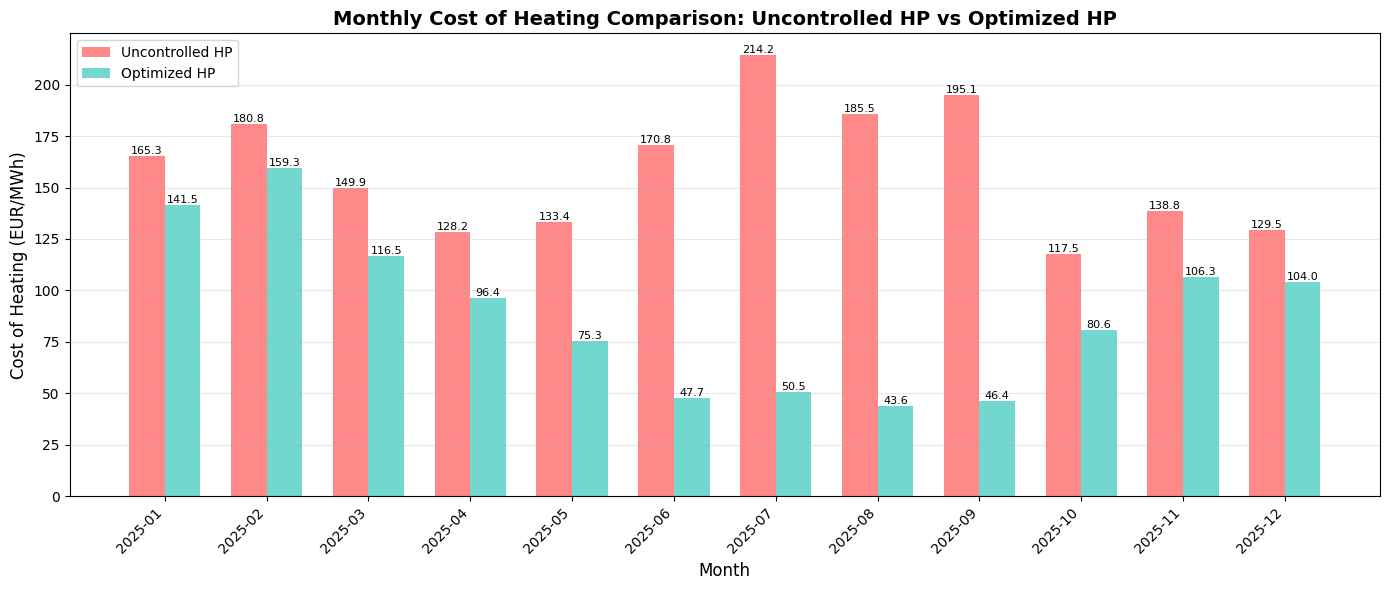

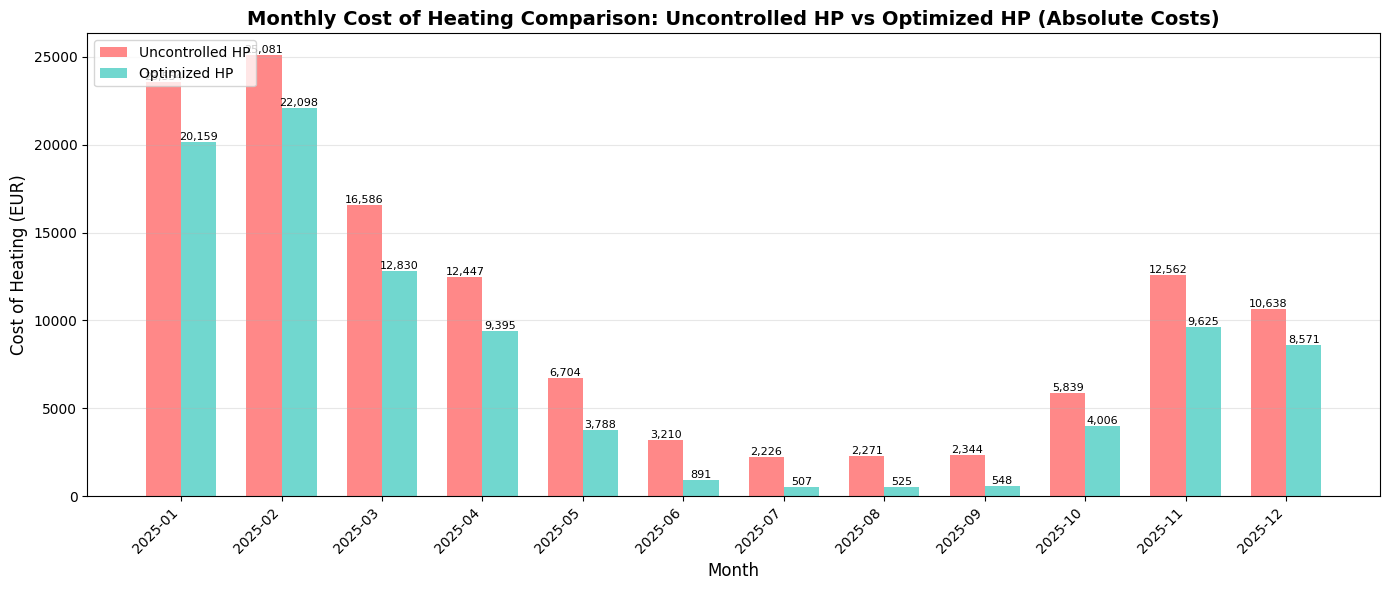

COST OF HEATING COMPARISON SUMMARY

Uncontrolled HP:
  Total HP electrical volume:          814.95 MWh
  Total net delta cost:            123,464.10 EUR
  Yearly cost of heating:             151.50 EUR/MWh

Optimized HP:
  Total HP electrical volume:          814.26 MWh
  Total net delta cost:             92,941.55 EUR
  Yearly cost of heating:             114.14 EUR/MWh

Savings:
  Savings per MWh:                      37.36 EUR/MWh
  Percentual decrease:                 24.66 %
  Total savings:                    30,522.55 EUR  (Δ uncontrolled − Δ optimized; same as full-site comparison)

Monthly Cost of Heating Comparison:
  Month  Uncontrolled (EUR/MWh)  Optimized (EUR/MWh)  Savings (EUR/MWh)  Savings (%)
2025-01                  165.31               141.49              23.82        14.41
2025-02                  180.83               159.28              21.55        11.92
2025-03                  149.93               116.48              33.45        22.31
2025-04                  1

In [10]:
# Cost of Heating Comparison: Uncontrolled HP vs Optimized HP
# Compare cost of heating per month for both scenarios

# Calculate monthly HP volumes
# For uncontrolled HP: use hp_load_df (uncontrolled HP)
hp_load_df['timestamp'] = pd.to_datetime(hp_load_df['timestamp'], utc=True)
hp_load_df['timestamp'] = hp_load_df['timestamp'].dt.tz_localize(None)
hp_load_df['month'] = pd.to_datetime(hp_load_df['timestamp']).dt.to_period('M')
monthly_hp_volume_uncontrolled = hp_load_df.groupby('month')['hp_electrical_load'].sum() / 1000  # Convert to MWh
monthly_hp_volume_uncontrolled_dict = {str(month): volume for month, volume in monthly_hp_volume_uncontrolled.items()}

# For optimized HP: use results_df
results_df['timestamp'] = pd.to_datetime(results_df['timestamp'])
results_df['month'] = pd.to_datetime(results_df['timestamp']).dt.to_period('M')
monthly_hp_volume_optimized = results_df.groupby('month')['hp_electrical_input'].sum() / 1000  # Convert to MWh
monthly_hp_volume_optimized_dict = {str(month): volume for month, volume in monthly_hp_volume_optimized.items()}

# Create comparison dataframe
heating_comparison = pd.DataFrame({
    'month': baseline_bills['month'],
})

# Calculate monthly delta costs
heating_comparison['baseline_hp_delta_cost'] = baseline_hp_bills['total_cost_eur'] - baseline_bills['total_cost_eur']
heating_comparison['baseline_hp_injection_delta'] = baseline_hp_injection['injection_net_revenue_eur'] - baseline_injection['injection_net_revenue_eur']
heating_comparison['baseline_hp_net_delta'] = heating_comparison['baseline_hp_delta_cost'] - heating_comparison['baseline_hp_injection_delta']

heating_comparison['optimized_delta_cost'] = optimized_bills['total_cost_eur'] - baseline_bills['total_cost_eur']
heating_comparison['optimized_injection_delta'] = optimized_injection['injection_net_revenue_eur'] - baseline_injection['injection_net_revenue_eur']
heating_comparison['optimized_net_delta'] = heating_comparison['optimized_delta_cost'] - heating_comparison['optimized_injection_delta']

# Map HP volumes
heating_comparison['hp_volume_uncontrolled_mwh'] = heating_comparison['month'].astype(str).map(monthly_hp_volume_uncontrolled_dict).fillna(0.0)
heating_comparison['hp_volume_optimized_mwh'] = heating_comparison['month'].astype(str).map(monthly_hp_volume_optimized_dict).fillna(0.0)

# Calculate cost of heating (EUR/MWh) = net_delta / hp_volume_mwh
heating_comparison['cost_of_heating_uncontrolled'] = heating_comparison['baseline_hp_net_delta'] / heating_comparison['hp_volume_uncontrolled_mwh'].replace(0, np.nan)
heating_comparison['cost_of_heating_optimized'] = heating_comparison['optimized_net_delta'] / heating_comparison['hp_volume_optimized_mwh'].replace(0, np.nan)

# Calculate savings per month
heating_comparison['savings_eur_per_mwh'] = heating_comparison['cost_of_heating_uncontrolled'] - heating_comparison['cost_of_heating_optimized']
heating_comparison['savings_percent'] = (heating_comparison['savings_eur_per_mwh'] / heating_comparison['cost_of_heating_uncontrolled'] * 100).fillna(0)

# Filter out months with zero HP volume
valid_months = (heating_comparison['hp_volume_uncontrolled_mwh'] > 0) & (heating_comparison['hp_volume_optimized_mwh'] > 0)
heating_comparison_valid = heating_comparison[valid_months].copy()

# Create comparison plot
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(heating_comparison_valid))
width = 0.35

# Plot bars for both scenarios
bars1 = ax.bar(x - width/2, heating_comparison_valid['cost_of_heating_uncontrolled'], width,
               label='Uncontrolled HP', color='#FF6B6B', alpha=0.8)
bars2 = ax.bar(x + width/2, heating_comparison_valid['cost_of_heating_optimized'], width,
               label='Optimized HP', color='#4ECDC4', alpha=0.8)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Cost of Heating (EUR/MWh)', fontsize=12)
ax.set_title('Monthly Cost of Heating Comparison: Uncontrolled HP vs Optimized HP', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(heating_comparison_valid['month'], rotation=45, ha='right')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height) and height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Create comparison plot showing absolute costs in EUR
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(heating_comparison_valid))
width = 0.35

# Plot bars for both scenarios showing absolute monthly costs
bars1 = ax.bar(x - width/2, heating_comparison_valid['baseline_hp_net_delta'], width,
               label='Uncontrolled HP', color='#FF6B6B', alpha=0.8)
bars2 = ax.bar(x + width/2, heating_comparison_valid['optimized_net_delta'], width,
               label='Optimized HP', color='#4ECDC4', alpha=0.8)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Cost of Heating (EUR)', fontsize=12)
ax.set_title('Monthly Cost of Heating Comparison: Uncontrolled HP vs Optimized HP (Absolute Costs)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(heating_comparison_valid['month'], rotation=45, ha='right')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height) and height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Calculate yearly statistics
total_hp_volume_uncontrolled = heating_comparison['hp_volume_uncontrolled_mwh'].sum()
total_hp_volume_optimized = heating_comparison['hp_volume_optimized_mwh'].sum()
total_delta_uncontrolled = heating_comparison['baseline_hp_net_delta'].sum()
total_delta_optimized = heating_comparison['optimized_net_delta'].sum()

yearly_cost_uncontrolled = total_delta_uncontrolled / total_hp_volume_uncontrolled if total_hp_volume_uncontrolled > 0 else np.nan
yearly_cost_optimized = total_delta_optimized / total_hp_volume_optimized if total_hp_volume_optimized > 0 else np.nan

yearly_savings_eur_per_mwh = yearly_cost_uncontrolled - yearly_cost_optimized
yearly_savings_percent = (yearly_savings_eur_per_mwh / yearly_cost_uncontrolled * 100) if yearly_cost_uncontrolled > 0 else 0

# True incremental savings (matches COST COMPARISON: Baseline+HP vs Optimized HP net totals).
# Do NOT use yearly_savings_eur_per_mwh * total_hp_volume_optimized when V_uncontrolled != V_optimized:
# (Δ_uc/V_uc - Δ_opt/V_opt)*V_opt ≠ Δ_uc - Δ_opt (error ~ Δ_uc * (1 - V_opt/V_uc)).
total_savings_heating_eur = total_delta_uncontrolled - total_delta_optimized

# Print summary statistics
print("="*80)
print("COST OF HEATING COMPARISON SUMMARY")
print("="*80)
print(f"\nUncontrolled HP:")
print(f"  Total HP electrical volume: {total_hp_volume_uncontrolled:>15,.2f} MWh")
print(f"  Total net delta cost:       {total_delta_uncontrolled:>15,.2f} EUR")
print(f"  Yearly cost of heating:    {yearly_cost_uncontrolled:>15,.2f} EUR/MWh")

print(f"\nOptimized HP:")
print(f"  Total HP electrical volume: {total_hp_volume_optimized:>15,.2f} MWh")
print(f"  Total net delta cost:       {total_delta_optimized:>15,.2f} EUR")
print(f"  Yearly cost of heating:    {yearly_cost_optimized:>15,.2f} EUR/MWh")

print(f"\nSavings:")
print(f"  Savings per MWh:            {yearly_savings_eur_per_mwh:>15,.2f} EUR/MWh")
print(f"  Percentual decrease:       {yearly_savings_percent:>15,.2f} %")
print(f"  Total savings:              {total_savings_heating_eur:>15,.2f} EUR  (Δ uncontrolled − Δ optimized; same as full-site comparison)")
print("="*80)

# Display monthly comparison table
print("\nMonthly Cost of Heating Comparison:")
display_cols = ['month', 'cost_of_heating_uncontrolled', 'cost_of_heating_optimized', 'savings_eur_per_mwh', 'savings_percent']
display_df = heating_comparison_valid[display_cols].copy()
display_df.columns = ['Month', 'Uncontrolled (EUR/MWh)', 'Optimized (EUR/MWh)', 'Savings (EUR/MWh)', 'Savings (%)']
display_df = display_df.round(2)
print(display_df.to_string(index=False))


In [11]:
# Export deterministic HP MPC results for reuse in online notebooks (Notebook 10)

from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
NOTEBOOKS_OUTPUT_DIR = PROJECT_ROOT / "output" / "notebooks"
NOTEBOOKS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 15-min deterministic results (full year)
export_det_15min = results_df.copy()
export_det_15min["timestamp"] = pd.to_datetime(export_det_15min["timestamp"], errors="coerce")
export_det_15min_path = NOTEBOOKS_OUTPUT_DIR / "deterministic_hp_15min_notebook_03.csv"
export_det_15min.to_csv(export_det_15min_path, index=False)

# Monthly deterministic bills (offtake)
export_det_monthly_bills = optimized_bills.copy()
export_det_monthly_bills_path = NOTEBOOKS_OUTPUT_DIR / "deterministic_hp_monthly_bills_notebook_03.csv"
export_det_monthly_bills.to_csv(export_det_monthly_bills_path, index=False)

# Monthly deterministic injection bills
export_det_monthly_inj = optimized_injection.copy()
export_det_monthly_inj_path = NOTEBOOKS_OUTPUT_DIR / "deterministic_hp_monthly_injection_notebook_03.csv"
export_det_monthly_inj.to_csv(export_det_monthly_inj_path, index=False)

print("Exported deterministic HP MPC results:")
print(f"- 15-min results:        {export_det_15min_path}")
print(f"- Monthly bills:         {export_det_monthly_bills_path}")
print(f"- Monthly injection:     {export_det_monthly_inj_path}")


Exported deterministic HP MPC results:
- 15-min results:        C:\Users\VanAmmeT\Documents\Masterproef\Master-Thesis-MPC-Soudal\output\notebooks\deterministic_hp_15min_notebook_03.csv
- Monthly bills:         C:\Users\VanAmmeT\Documents\Masterproef\Master-Thesis-MPC-Soudal\output\notebooks\deterministic_hp_monthly_bills_notebook_03.csv
- Monthly injection:     C:\Users\VanAmmeT\Documents\Masterproef\Master-Thesis-MPC-Soudal\output\notebooks\deterministic_hp_monthly_injection_notebook_03.csv


## Buffer Size Sensitivity Analysis

This section performs a **sensitivity analysis** to determine the optimal buffer size for the heat pump system by comparing different buffer capacities and their impact on operational costs.

**What this analysis does:**
- **Multiple optimizations**: Runs the deterministic MPC optimization for different buffer sizes:
  - Fine-grained analysis: 10-100 m³ in steps of 10 m³ (10, 20, 30, ..., 100 m³)
  - Coarse-grained analysis: 50-400 m³ in steps of 50 m³ (50, 100, 150, ..., 400 m³)
  - Total: 16 different buffer sizes tested

- **For each buffer size:**
  - Calculates uncontrolled HP baseline costs
  - Runs optimization with that specific buffer size
  - Calculates optimized costs and cost of heating (EUR/MWh)
  - Performs economic analysis (CAPEX, payback time, NPV, IRR)

**What you'll see:**
- **Cost comparison table** showing:
  - Cost of heating (EUR/MWh) for each buffer size
  - Total cost (EUR) for each buffer size
  - HP volume (MWh) consumed

- **Economic analysis table** showing:
  - CAPEX (EUR) - one-time investment cost
  - Annual savings (EUR) vs uncontrolled HP
  - Payback time (years)
  - NPV (EUR) - Net Present Value over 25 years
  - IRR (%) - Internal Rate of Return

- **Visualizations:**
  - Cost of heating vs buffer size (bar chart)
  - Payback time vs buffer size
  - NPV vs buffer size
  - IRR vs buffer size
  - Annual savings vs CAPEX (scatter plot)

**Key insights:**
- Larger buffers provide more flexibility for load shifting, potentially reducing costs
- However, larger buffers have higher CAPEX costs
- The analysis helps identify the optimal buffer size that balances operational savings with investment costs
- Economic metrics (NPV, IRR, payback time) help assess the financial viability of different buffer sizes

**Note:** Each optimization takes approximately 3 minutes, so the full analysis takes about 45-50 minutes to complete.

**Caching:** After the first run, MPC results are stored in `output/optimised_ts/deterministic_hp_*m3.csv` and the summary table in `output/notebooks/buffer_size_sensitivity_summary_notebook_03.csv`. Leave `RERUN_BUFFER_SENSITIVITY = False` (default) to skip re-optimisation; set it to `True` only when you need fresh MPC runs.

In [12]:
# Buffer Size Sensitivity Analysis
# Run optimization for different buffer sizes and compare cost of heating
# Includes fine-grained analysis (10-100m³ in steps of 10) and coarse-grained (50-400m³)
# Includes economic analysis: IRR, payback time, NPV

import sys
import importlib
import yaml
from pathlib import Path
sys.path.append(str(Path("..") / "src"))

# Reload module to pick up any changes
import buffer_size_sensitivity
importlib.reload(buffer_size_sensitivity)
from buffer_size_sensitivity import (
    run_buffer_size_sensitivity,
    default_sensitivity_summary_path,
    sensitivity_optimisations_on_disk,
)

# Set True only when you want to re-run all ~45 min of MPC optimisations
RERUN_BUFFER_SENSITIVITY = False

PROJECT_ROOT = Path("..").resolve()
SENSITIVITY_SUMMARY_PATH = default_sensitivity_summary_path(PROJECT_ROOT)
OPT_OUTPUT_DIR = PROJECT_ROOT / "output" / "optimised_ts"

# Define buffer sizes to test: fine-grained (10-100m³ in steps of 10) + coarse-grained (50-400m³)
buffer_sizes_fine = list(range(10, 101, 10))
buffer_sizes_coarse = [50, 100, 150, 200, 250, 300, 350, 400]
buffer_sizes = sorted(list(set(buffer_sizes_fine + buffer_sizes_coarse)))

print(f"\nTesting buffer sizes: {buffer_sizes} m³")
print(f"Total number of optimisations: {len(buffer_sizes)}")

use_cached_runs = (
    not RERUN_BUFFER_SENSITIVITY
    and sensitivity_optimisations_on_disk(buffer_sizes, OPT_OUTPUT_DIR)
)

if use_cached_runs:
    print("\nSkipping MPC re-runs — cached optimised time series found.")
    print(f"  Directory: {OPT_OUTPUT_DIR}")
    print(f"  Summary:   {SENSITIVITY_SUMMARY_PATH} (loaded in next cell if present)")
    print("  Set RERUN_BUFFER_SENSITIVITY = True in this cell to force a full re-run.")
    results = None
    baseline_net_total = None
else:
    results, baseline_net_total = run_buffer_size_sensitivity(
        df=df,
        billing_config_path="../config/billing.yaml",
        hp_config_path="../config/hp.yaml",
        buffer_sizes=buffer_sizes,
        output_dir=str(OPT_OUTPUT_DIR),
    )



Testing buffer sizes: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200, 250, 300, 350, 400] m³
Total number of optimizations: 16
Calculating baseline costs (no HP)...
Calculating uncontrolled HP costs...
Heat pump load calculated and saved to C:\Users\VanAmmeT\AppData\Local\Temp\tmpct7x6jbr.csv
Total electrical load: 815099.69 kWh (815.10 MWh)
Average COP: 2.57
Min COP: 2.22, Max COP: 3.12
  Heuristic HP AP add-on (worst case @ -10°C): +337.78 kW (max thermal 177.33 kWh/15min → 709.3 kW thermal / COP 2.10)
  ✓ Uncontrolled HP cost of heating: 151.47 EUR/MWh
BUFFER SIZE SENSITIVITY ANALYSIS
Testing buffer sizes: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200, 250, 300, 350, 400] m³
Output directory: ../output/optimised_ts

Optimizing 10m³...
Deterministic MPC Optimization for Heat Pump System

[1/10] Loading billing configuration from: ../config/billing.yaml
   ✓ Billing configuration loaded

[2/10] Loading HP configuration from: C:\Users\VanAmmeT\AppData\Local\Temp\tmp_pn1m_ny.y

Economic Parameters:
  Cost of capital: 5.0%
  Buffer lifetime: 25 years
  Buffer CAPEX: 1400 EUR/m³

BUFFER SIZE SENSITIVITY ANALYSIS RESULTS (ALL SIZES)

Cost of Heating Comparison:
Buffer Size (m³)  Cost of Heating (EUR/MWh)  HP Volume (MWh)
    Uncontrolled                 151.471161       815.099687
              10                 131.677048       815.035713
              20                 125.917539       814.936171
              30                 122.655823       814.823694
              40                 119.957901       814.703598
              50                 118.236103       814.587065
              60                 116.763982       814.469579
              70                 115.409043       814.358991
              80                 114.141982       814.262590
              90                 112.951847       814.180140
             100                 111.818595       814.116878
             150                 107.126880       814.043733
             200       

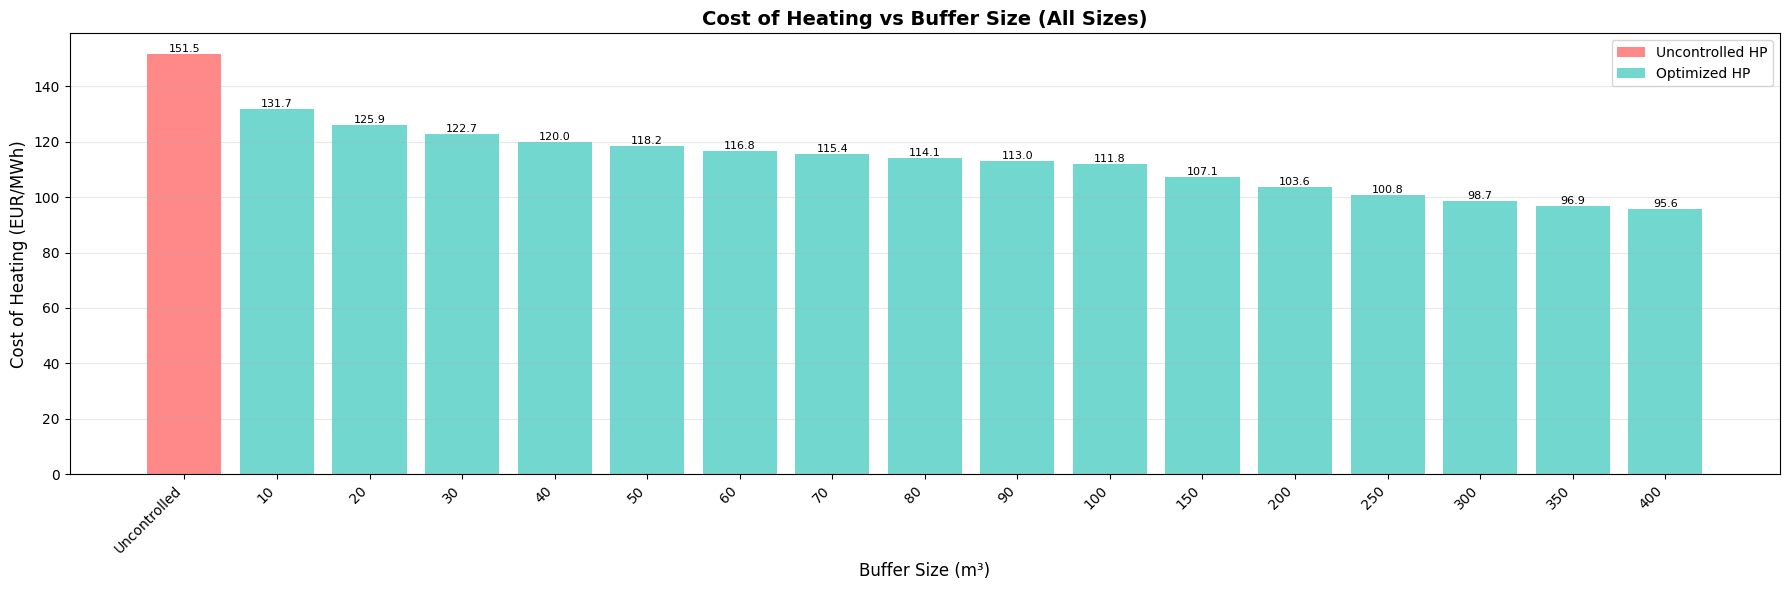

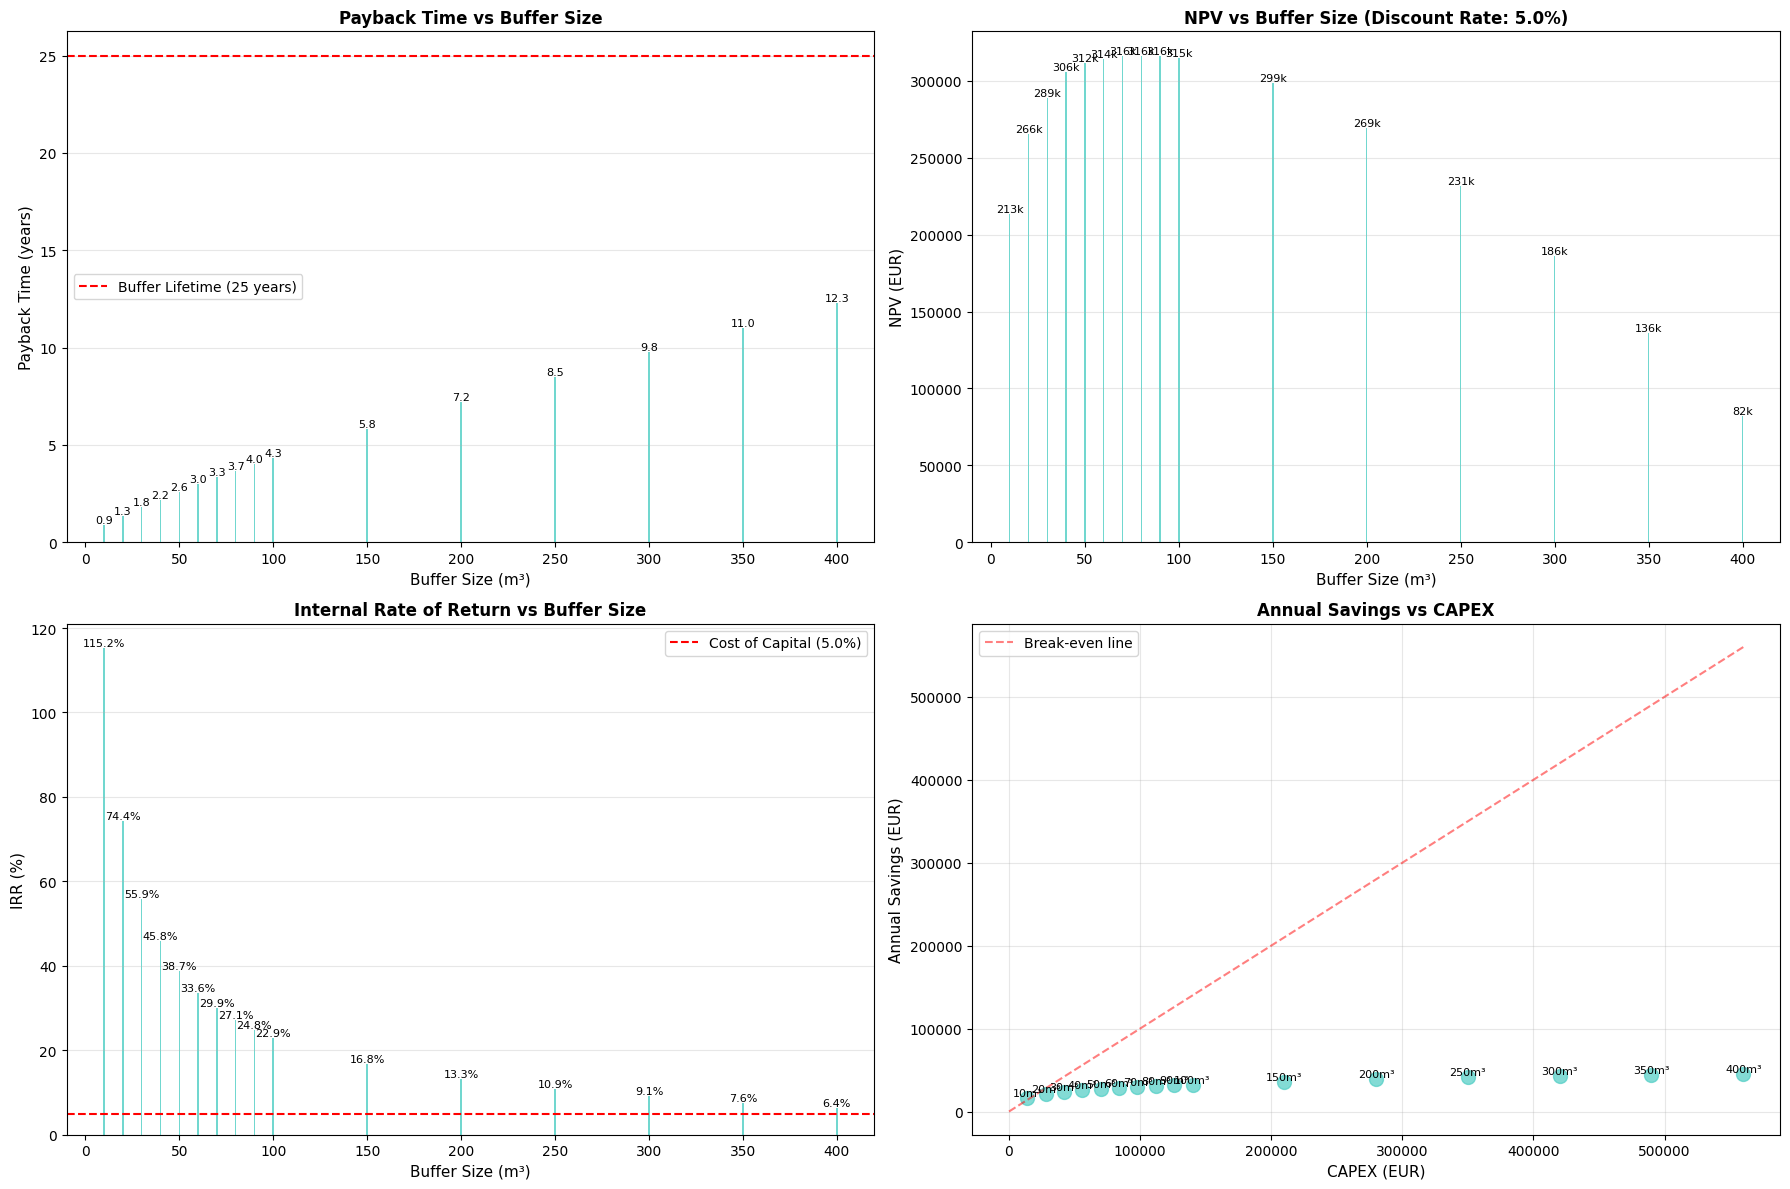


Percentual Decrease vs Uncontrolled HP (All Sizes):
--------------------------------------------------------------------------------
  10m³: 13.07% decrease (151.47 → 131.68 EUR/MWh)
  20m³: 16.87% decrease (151.47 → 125.92 EUR/MWh)
  30m³: 19.02% decrease (151.47 → 122.66 EUR/MWh)
  40m³: 20.80% decrease (151.47 → 119.96 EUR/MWh)
  50m³: 21.94% decrease (151.47 → 118.24 EUR/MWh)
  60m³: 22.91% decrease (151.47 → 116.76 EUR/MWh)
  70m³: 23.81% decrease (151.47 → 115.41 EUR/MWh)
  80m³: 24.64% decrease (151.47 → 114.14 EUR/MWh)
  90m³: 25.43% decrease (151.47 → 112.95 EUR/MWh)
  100m³: 26.18% decrease (151.47 → 111.82 EUR/MWh)
  150m³: 29.28% decrease (151.47 → 107.13 EUR/MWh)
  200m³: 31.61% decrease (151.47 → 103.60 EUR/MWh)
  250m³: 33.44% decrease (151.47 → 100.83 EUR/MWh)
  300m³: 34.86% decrease (151.47 → 98.67 EUR/MWh)
  350m³: 36.00% decrease (151.47 → 96.94 EUR/MWh)
  400m³: 36.89% decrease (151.47 → 95.60 EUR/MWh)


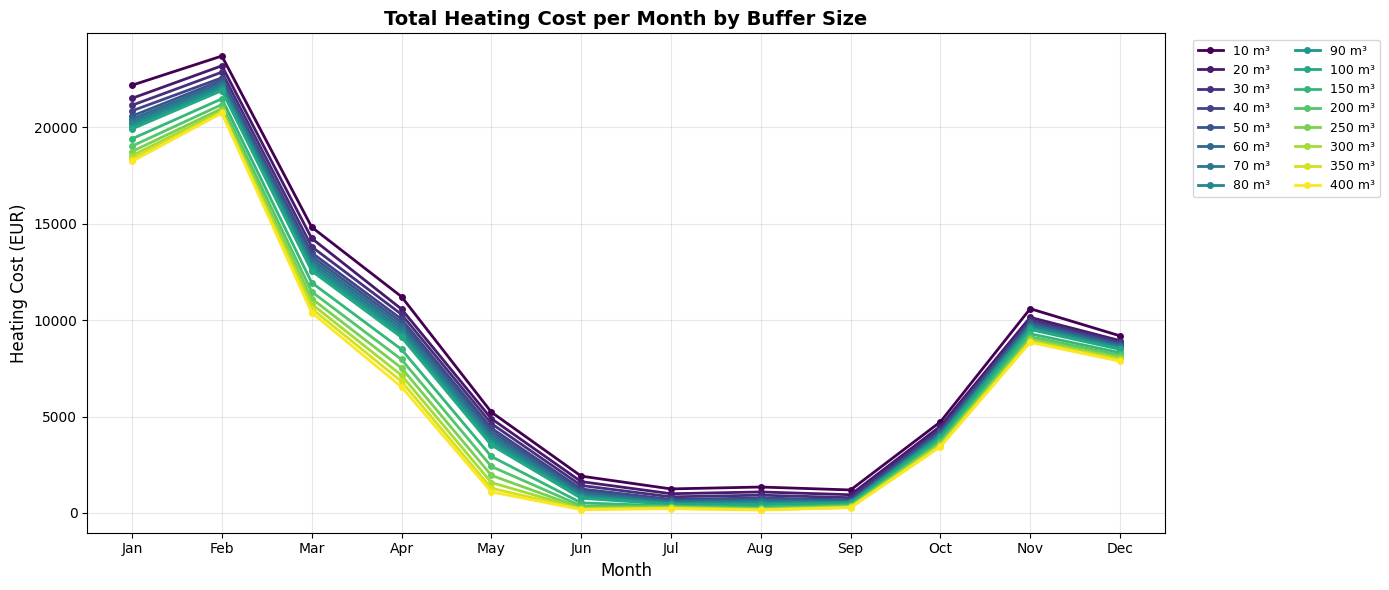

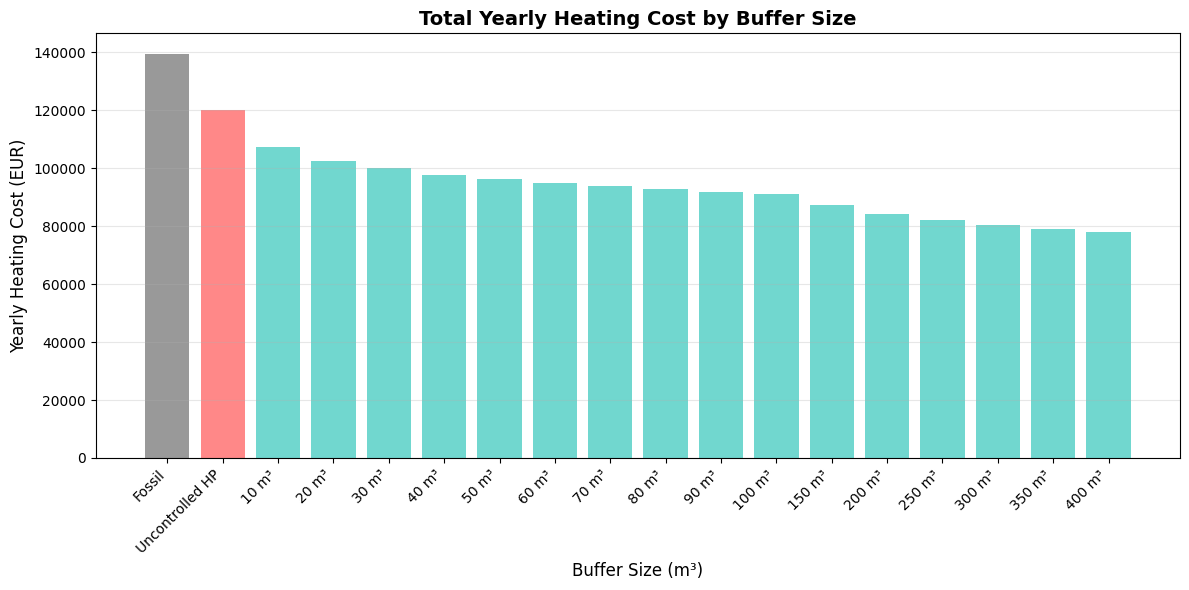

In [13]:
# Load economic parameters from hp.yaml
with open("../config/hp.yaml", 'r') as f:
    hp_config = yaml.safe_load(f)
    
cost_of_capital = hp_config['economics']['cost_of_capital']
buffer_lifetime = hp_config['economics']['buffer_lifetime_years']
buffer_capex_per_m3 = hp_config['economics']['buffer_capex_per_m3']

print(f"Economic Parameters:")
print(f"  Cost of capital: {cost_of_capital*100:.1f}%")
print(f"  Buffer lifetime: {buffer_lifetime} years")
print(f"  Buffer CAPEX: {buffer_capex_per_m3:.0f} EUR/m³")

# Economic analysis functions
def calculate_payback_time(capex, annual_savings):
    """Calculate payback time in years"""
    if annual_savings <= 0:
        return np.inf
    return capex / annual_savings

def calculate_npv(annual_savings, capex, discount_rate, lifetime):
    """Calculate Net Present Value"""
    if annual_savings <= 0:
        return -capex
    # NPV = -CAPEX + sum(annual_savings / (1 + r)^t) for t = 1 to lifetime
    npv = -capex
    for year in range(1, lifetime + 1):
        npv += annual_savings / ((1 + discount_rate) ** year)
    return npv

def calculate_irr(annual_savings, capex, lifetime, max_iterations=100):
    """Calculate Internal Rate of Return using Newton-Raphson method"""
    if annual_savings <= 0:
        return -np.inf
    
    # Initial guess
    irr = 0.1
    
    for _ in range(max_iterations):
        # Calculate NPV at current IRR
        npv = -capex
        npv_derivative = 0
        for year in range(1, lifetime + 1):
            discount_factor = (1 + irr) ** year
            npv += annual_savings / discount_factor
            npv_derivative -= year * annual_savings / (discount_factor * (1 + irr))
        
        # Newton-Raphson update
        if abs(npv_derivative) < 1e-10:
            break
        irr_new = irr - npv / npv_derivative
        
        # Check convergence
        if abs(irr_new - irr) < 1e-8:
            irr = irr_new
            break
        irr = irr_new
    
    return irr


from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
SENSITIVITY_SUMMARY_PATH = default_sensitivity_summary_path(PROJECT_ROOT)
OPT_OUTPUT_DIR = PROJECT_ROOT / "output" / "optimised_ts"

from buffer_size_sensitivity import (
    default_sensitivity_summary_path,
    load_sensitivity_summary,
    save_sensitivity_summary,
    load_results_from_optimised_csv,
    sensitivity_optimisations_on_disk,
)

comparison_df = None
if results is None:
    if SENSITIVITY_SUMMARY_PATH.exists():
        comparison_df = load_sensitivity_summary(SENSITIVITY_SUMMARY_PATH)
        print(f"Loaded comparison table from cache: {SENSITIVITY_SUMMARY_PATH}")
    elif sensitivity_optimisations_on_disk(buffer_sizes, OPT_OUTPUT_DIR):
        print("Rebuilding comparison table from cached deterministic_hp_*m3.csv (no MPC)...")
        results, baseline_net_total = load_results_from_optimised_csv(
            df=df,
            billing_config_path="../config/billing.yaml",
            hp_config_path="../config/hp.yaml",
            buffer_sizes=buffer_sizes,
            output_dir=str(OPT_OUTPUT_DIR),
        )
    else:
        raise FileNotFoundError(
            "No cached sensitivity results. Run the cell above with "
            "RERUN_BUFFER_SENSITIVITY = True first."
        )

if comparison_df is None:
    # Create comparison table with economic metrics
    comparison_data = []
    uncontrolled_cost = None
    uncontrolled_hp_volume = None

    # Get uncontrolled baseline
    if 'uncontrolled' in results:
        uncontrolled = results['uncontrolled']
        uncontrolled_cost = uncontrolled['cost_of_heating_eur_per_mwh']
        uncontrolled_hp_volume = uncontrolled['hp_volume_mwh']
        comparison_data.append({
            'Buffer Size (m³)': 'Uncontrolled',
            'Cost of Heating (EUR/MWh)': uncontrolled_cost,
            'Total Cost (EUR)': uncontrolled['delta_cost'],
            'HP Volume (MWh)': uncontrolled_hp_volume,
            'CAPEX (EUR)': np.nan,
            'Annual Savings (EUR)': np.nan,
            'Payback Time (years)': np.nan,
            'NPV (EUR)': np.nan,
            'IRR (%)': np.nan
        })

    # Add optimized results for each buffer size with economic analysis
    for buffer_size in sorted(buffer_sizes):
        if buffer_size in results:
            result = results[buffer_size]
            optimized_cost = result['cost_of_heating_eur_per_mwh']
            hp_volume = result['hp_volume_mwh']
        
            # Calculate annual savings vs uncontrolled
            if uncontrolled_cost is not None and uncontrolled_hp_volume is not None:
                annual_savings = (uncontrolled_cost - optimized_cost) * hp_volume
            else:
                annual_savings = np.nan
        
            # Calculate CAPEX
            capex = buffer_size * buffer_capex_per_m3
        
            # Calculate economic metrics
            if not np.isnan(annual_savings) and annual_savings > 0:
                payback_time = calculate_payback_time(capex, annual_savings)
                npv = calculate_npv(annual_savings, capex, cost_of_capital, buffer_lifetime)
                irr = calculate_irr(annual_savings, capex, buffer_lifetime)
            else:
                payback_time = np.inf
                npv = -capex
                irr = -np.inf
        
            comparison_data.append({
                'Buffer Size (m³)': f'{buffer_size}',
                'Cost of Heating (EUR/MWh)': optimized_cost,
                'Total Cost (EUR)': result['delta_cost'],
                'HP Volume (MWh)': hp_volume,
                'CAPEX (EUR)': capex,
                'Annual Savings (EUR)': annual_savings,
                'Payback Time (years)': payback_time,
                'NPV (EUR)': npv,
                'IRR (%)': irr * 100
            })

    comparison_df = pd.DataFrame(comparison_data)

    comparison_df = pd.DataFrame(comparison_data)
    save_sensitivity_summary(comparison_df, SENSITIVITY_SUMMARY_PATH)
    print(f"Saved comparison table to: {SENSITIVITY_SUMMARY_PATH}")

# Display comparison table
print("\n" + "="*80)
print("BUFFER SIZE SENSITIVITY ANALYSIS RESULTS (ALL SIZES)")
print("="*80)
print("\nCost of Heating Comparison:")
print(comparison_df[['Buffer Size (m³)', 'Cost of Heating (EUR/MWh)', 'HP Volume (MWh)']].to_string(index=False))
print("\nEconomic Analysis:")
econ_cols = ['Buffer Size (m³)', 'CAPEX (EUR)', 'Annual Savings (EUR)', 'Payback Time (years)', 'NPV (EUR)', 'IRR (%)']
print(comparison_df[econ_cols].to_string(index=False))
print("="*80)

# Create comparison plot - Cost of Heating (no color differences)
fig, ax = plt.subplots(figsize=(18, 6))

buffer_labels = comparison_df['Buffer Size (m³)'].values
costs = comparison_df['Cost of Heating (EUR/MWh)'].values

# Single color for all optimized (except uncontrolled)
colors = ['#FF6B6B' if label == 'Uncontrolled' else '#4ECDC4' for label in buffer_labels]
bars = ax.bar(range(len(buffer_labels)), costs, color=colors, alpha=0.8)

ax.set_xlabel('Buffer Size (m³)', fontsize=12)
ax.set_ylabel('Cost of Heating (EUR/MWh)', fontsize=12)
ax.set_title('Cost of Heating vs Buffer Size (All Sizes)', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(buffer_labels)))
ax.set_xticklabels(buffer_labels, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, cost in zip(bars, costs):
    if not np.isnan(cost):
        ax.text(bar.get_x() + bar.get_width()/2., cost,
                f'{cost:.1f}', ha='center', va='bottom', fontsize=8)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF6B6B', alpha=0.8, label='Uncontrolled HP'),
    Patch(facecolor='#4ECDC4', alpha=0.8, label='Optimized HP')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Economic metrics plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Filter out uncontrolled for economic plots
econ_df = comparison_df[comparison_df['Buffer Size (m³)'] != 'Uncontrolled'].copy()
econ_buffer_sizes = [int(x) for x in econ_df['Buffer Size (m³)'].values]

# Plot 1: Payback Time
ax1 = axes[0, 0]
payback_times = econ_df['Payback Time (years)'].values
# Replace infinity with a large number for plotting
payback_times_plot = [min(pt, buffer_lifetime * 2) if not np.isinf(pt) else buffer_lifetime * 2 for pt in payback_times]
bars1 = ax1.bar(econ_buffer_sizes, payback_times_plot, color='#4ECDC4', alpha=0.8)
ax1.axhline(y=buffer_lifetime, color='r', linestyle='--', label=f'Buffer Lifetime ({buffer_lifetime} years)')
ax1.set_xlabel('Buffer Size (m³)', fontsize=11)
ax1.set_ylabel('Payback Time (years)', fontsize=11)
ax1.set_title('Payback Time vs Buffer Size', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.legend()
for bar, pt in zip(bars1, payback_times):
    if not np.isinf(pt):
        ax1.text(bar.get_x() + bar.get_width()/2., min(pt, buffer_lifetime * 2),
                f'{pt:.1f}', ha='center', va='bottom', fontsize=8)

# Plot 2: NPV
ax2 = axes[0, 1]
npvs = econ_df['NPV (EUR)'].values
bars2 = ax2.bar(econ_buffer_sizes, npvs, color='#4ECDC4', alpha=0.8)
ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Buffer Size (m³)', fontsize=11)
ax2.set_ylabel('NPV (EUR)', fontsize=11)
ax2.set_title(f'NPV vs Buffer Size (Discount Rate: {cost_of_capital*100:.1f}%)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
for bar, npv in zip(bars2, npvs):
    if not np.isnan(npv):
        ax2.text(bar.get_x() + bar.get_width()/2., npv,
                f'{npv/1000:.0f}k', ha='center', va='bottom' if npv >= 0 else 'top', fontsize=8)

# Plot 3: IRR
ax3 = axes[1, 0]
irrs = econ_df['IRR (%)'].values
# Replace -infinity with a low value for plotting
irrs_plot = [max(irr, -50) if not np.isinf(irr) else -50 for irr in irrs]
bars3 = ax3.bar(econ_buffer_sizes, irrs_plot, color='#4ECDC4', alpha=0.8)
ax3.axhline(y=cost_of_capital*100, color='r', linestyle='--', label=f'Cost of Capital ({cost_of_capital*100:.1f}%)')
ax3.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax3.set_xlabel('Buffer Size (m³)', fontsize=11)
ax3.set_ylabel('IRR (%)', fontsize=11)
ax3.set_title('Internal Rate of Return vs Buffer Size', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
ax3.legend()
for bar, irr in zip(bars3, irrs):
    if not np.isinf(irr):
        ax3.text(bar.get_x() + bar.get_width()/2., max(irr, -50),
                f'{irr:.1f}%', ha='center', va='bottom' if irr >= 0 else 'top', fontsize=8)

# Plot 4: Annual Savings vs CAPEX
ax4 = axes[1, 1]
annual_savings = econ_df['Annual Savings (EUR)'].values
capex_values = econ_df['CAPEX (EUR)'].values
ax4.scatter(capex_values, annual_savings, s=100, alpha=0.7, color='#4ECDC4')
# Add buffer size labels
for i, (cx, sav, bs) in enumerate(zip(capex_values, annual_savings, econ_buffer_sizes)):
    ax4.annotate(f'{bs}m³', (cx, sav), fontsize=8, ha='center', va='bottom')
# Add break-even line (45-degree line)
max_val = max(max(capex_values), max(annual_savings))
ax4.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Break-even line')
ax4.set_xlabel('CAPEX (EUR)', fontsize=11)
ax4.set_ylabel('Annual Savings (EUR)', fontsize=11)
ax4.set_title('Annual Savings vs CAPEX', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

# Calculate percentual decrease compared to uncontrolled
_uc = comparison_df.loc[comparison_df["Buffer Size (m³)"] == "Uncontrolled", "Cost of Heating (EUR/MWh)"]
if not _uc.empty:
    uncontrolled_cost = float(pd.to_numeric(_uc.iloc[0], errors="coerce"))
    print("\nPercentual Decrease vs Uncontrolled HP (All Sizes):")
    print("-"*80)
    _opt = comparison_df[comparison_df["Buffer Size (m³)"] != "Uncontrolled"].copy()
    _opt["buffer_m3"] = pd.to_numeric(_opt["Buffer Size (m³)"], errors="coerce")
    for _, row in _opt.sort_values("buffer_m3").iterrows():
        optimized_cost = float(pd.to_numeric(row["Cost of Heating (EUR/MWh)"], errors="coerce"))
        bs = int(row["buffer_m3"])
        if not np.isnan(uncontrolled_cost) and not np.isnan(optimized_cost) and uncontrolled_cost > 0:
            decrease_pct = ((uncontrolled_cost - optimized_cost) / uncontrolled_cost) * 100
            print(
                f"  {bs}m³: {decrease_pct:.2f}% decrease "
                f"({uncontrolled_cost:.2f} → {optimized_cost:.2f} EUR/MWh)"
            )
    print("="*80)

# Monthly plot: Total heating cost per buffer size
# Loads data from output folder (no optimization rerun)

import re
from pathlib import Path
import sys
sys.path.append(str(Path("..") / "src"))
import yaml
from billing import load_billing_config, calculate_monthly_bills, calculate_monthly_injection_bills

# Load baseline data (plant without HP)
df_baseline = pd.read_csv("../data/plant1.csv", parse_dates=["timestamp"])
df_baseline.columns = df_baseline.columns.str.strip()
config = load_billing_config("../config/billing.yaml")

# Conservative access power (previous max peak + 20 kW), same as main baseline section
ts_raw = df_baseline["timestamp"]
if ts_raw.dtype == "object" or isinstance(
    ts_raw.iloc[0] if len(ts_raw) else None, str
):
    ts_naive = ts_raw.astype(str).str.replace(r"[+-]\d{2}:\d{2}$", "", regex=True)
    ts_naive = pd.to_datetime(ts_naive, errors="coerce")
else:
    ts_naive = pd.to_datetime(ts_raw, errors="coerce")
    if ts_naive.dt.tz is not None:
        ts_naive = ts_naive.dt.tz_localize(None)

naive_timestamps = pd.to_datetime(
    ts_naive.dt.strftime("%Y-%m-%d %H:%M:%S"),
    format="%Y-%m-%d %H:%M:%S",
)
df_baseline["month"] = naive_timestamps.dt.to_period("M")

MARGIN_KW = 20.0
BASELINE_2024_PEAK_GRID_KW = 2663.5
months_2025 = pd.period_range("2025-01", "2025-12", freq="M")
monthly_peak_baseline_kw = (
    (df_baseline.groupby("month")["grid_consumption"].max() * 4.0)
    .reindex(months_2025)
    .fillna(0.0)
)
cummax_M_minus_1_kw = monthly_peak_baseline_kw.cummax().shift(1)
cummax_M_minus_1_kw.loc[months_2025.min()] = BASELINE_2024_PEAK_GRID_KW
cummax_M_minus_1_kw = cummax_M_minus_1_kw.fillna(BASELINE_2024_PEAK_GRID_KW)
access_power_conservative = cummax_M_minus_1_kw + MARGIN_KW
df_baseline["baseline_access_power_conservative"] = (
    df_baseline["month"].map(access_power_conservative.to_dict()).astype(float)
)

baseline_bills = calculate_monthly_bills(
    df_baseline,
    config,
    access_power_col="baseline_access_power_conservative",
)
baseline_injection = calculate_monthly_injection_bills(df_baseline, config)

# Discover and load deterministic_hp_*m3.csv files from output/optimised_ts
output_dir_opt = Path("../output/optimised_ts")
pattern = re.compile(r"deterministic_hp_(\d+)m3\.csv")
monthly_data = {}

for f in sorted(output_dir_opt.glob("deterministic_hp_*m3.csv")):
    m = pattern.match(f.name)
    if m:
        buffer_size = int(m.group(1))
        opt_df = pd.read_csv(f, parse_dates=["timestamp"])
        opt_df = opt_df.rename(columns={"spot_price": "price"})
        opt_bills = calculate_monthly_bills(opt_df, config, access_power_col="access_power")
        opt_injection = calculate_monthly_injection_bills(opt_df, config)
        optimized_net = opt_bills["total_cost_eur"].values - opt_injection["injection_net_revenue_eur"].values
        baseline_net = baseline_bills["total_cost_eur"].values - baseline_injection["injection_net_revenue_eur"].values
        monthly_data[buffer_size] = optimized_net - baseline_net

if not monthly_data:
    raise FileNotFoundError("No deterministic_hp_*m3.csv files found in ../output/optimised_ts")

# Load uncontrolled HP cost from output
uncontrolled_hp_cost = None
uncontrolled_hp_path = Path("../output") / "uncontrolled_hp.csv"
if uncontrolled_hp_path.exists():
    hp_load = pd.read_csv(uncontrolled_hp_path)
    ts = hp_load["timestamp"].astype(str).str.replace(r"[+-]\d{2}:\d{2}$", "", regex=True)
    hp_load["timestamp"] = pd.to_datetime(ts, errors="coerce")
    df_baseline_naive = df_baseline.copy()
    ts_bl = df_baseline_naive["timestamp"].astype(str).str.replace(r"[+-]\d{2}:\d{2}$", "", regex=True)
    df_baseline_naive["timestamp"] = pd.to_datetime(ts_bl, errors="coerce")
    df_uc = df_baseline_naive.merge(hp_load[["timestamp", "hp_electrical_load"]], on="timestamp", how="left")
    df_uc["hp_electrical_load"] = df_uc["hp_electrical_load"].fillna(0.0)
    df_uc["total_consumption_with_hp"] = df_uc["inflex_load"] + df_uc["ev"] + df_uc["hp_electrical_load"]
    df_uc["grid_consumption"] = np.maximum(0, df_uc["total_consumption_with_hp"] - df_uc["pv_production"])
    df_uc["grid_injection"] = np.maximum(0, df_uc["pv_production"] - df_uc["total_consumption_with_hp"])
    with open("../config/hp.yaml", "r") as f:
        hp_config = yaml.safe_load(f)
    hp_access = hp_config.get("Access_power_HP", {})
    df_uc["access_power_hp"] = df_uc["timestamp"].dt.strftime("%B").map(hp_access).fillna(3000.0)
    uc_bills = calculate_monthly_bills(df_uc, config, access_power_col="access_power_hp")
    uc_injection = calculate_monthly_injection_bills(df_uc, config)
    baseline_net_per_month = baseline_bills["total_cost_eur"].values - baseline_injection["injection_net_revenue_eur"].values
    uc_net_per_month = uc_bills["total_cost_eur"].values - uc_injection["injection_net_revenue_eur"].values
    uncontrolled_hp_cost = (uc_net_per_month - baseline_net_per_month).sum()

months = baseline_bills["month"].values
month_labels = [pd.Period(str(m)).strftime("%b") for m in months]
x = np.arange(len(months))

fig, ax = plt.subplots(figsize=(14, 6))
buffer_sizes_to_plot = sorted(monthly_data.keys())
colors = plt.cm.viridis(np.linspace(0, 1, len(buffer_sizes_to_plot)))

for i, buffer_size in enumerate(buffer_sizes_to_plot):
    monthly_heating_cost = monthly_data[buffer_size]
    ax.plot(x, monthly_heating_cost, marker="o", markersize=4, linewidth=2,
            label=f"{buffer_size} m³", color=colors[i])

ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Heating Cost (EUR)", fontsize=12)
ax.set_title("Total Heating Cost per Month by Buffer Size", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", ncol=2, fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.5, len(x) - 0.5)
plt.tight_layout()
plt.show()

# Yearly heating cost vs buffer size
fig2, ax2 = plt.subplots(figsize=(12, 6))
fossil_cost = 139625
buffer_sizes_sorted = sorted(monthly_data.keys())
x_labels = ["Fossil"]
heights = [fossil_cost]
colors_bar = ["gray"]
if uncontrolled_hp_cost is not None:
    x_labels.append("Uncontrolled HP")
    heights.append(uncontrolled_hp_cost)
    colors_bar.append("#FF6B6B")
x_labels += [f"{bs} m³" for bs in buffer_sizes_sorted]
heights += [monthly_data[bs].sum() for bs in buffer_sizes_sorted]
colors_bar += ["#4ECDC4"] * len(buffer_sizes_sorted)
x_pos = np.arange(len(x_labels))
ax2.bar(x_pos, heights, color=colors_bar, alpha=0.8)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(x_labels, rotation=45, ha="right")
ax2.set_xlabel("Buffer Size (m³)", fontsize=12)
ax2.set_ylabel("Yearly Heating Cost (EUR)", fontsize=12)
ax2.set_title("Total Yearly Heating Cost by Buffer Size", fontsize=14, fontweight="bold")
ax2.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


## Thesis figures — buffer size sensitivity

Caption-ready plots (KU Leuven style; see [`STYLE_GUIDE_PLOTS.md`](../STYLE_GUIDE_PLOTS.md)):

- **Cost of heating** (EUR/MWh) vs buffer size — optimized MPC vs uncontrolled HP reference
- **NPV** (EUR) vs buffer size — net NPV plus **CAPEX** (−investment) and **OPEX** (PV of annual operational savings)

**No MPC re-run:** the plot cell rebuilds the comparison table from `output/optimised_ts/deterministic_hp_*m3.csv` (billing only). Run buffer sensitivity (cell 21) once to generate those CSVs.


Loading comparison table from 16 CSV(s) in C:\Users\VanAmmeT\Documents\Masterproef\Master-Thesis-MPC-Soudal\output\optimised_ts (billing only, no MPC)...
Rebuilding uncontrolled HP metrics from plant data...
Heat pump load calculated and saved to C:\Users\VanAmmeT\AppData\Local\Temp\tmpkgss0eoa.csv
Total electrical load: 815099.69 kWh (815.10 MWh)
Average COP: 2.57
Min COP: 2.22, Max COP: 3.12
Loading 16 cached optimised HP schedules from C:\Users\VanAmmeT\Documents\Masterproef\Master-Thesis-MPC-Soudal\output\optimised_ts...


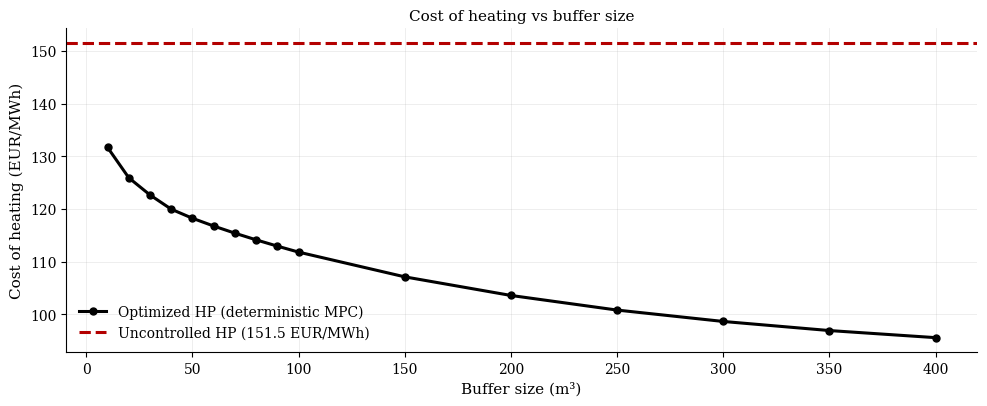

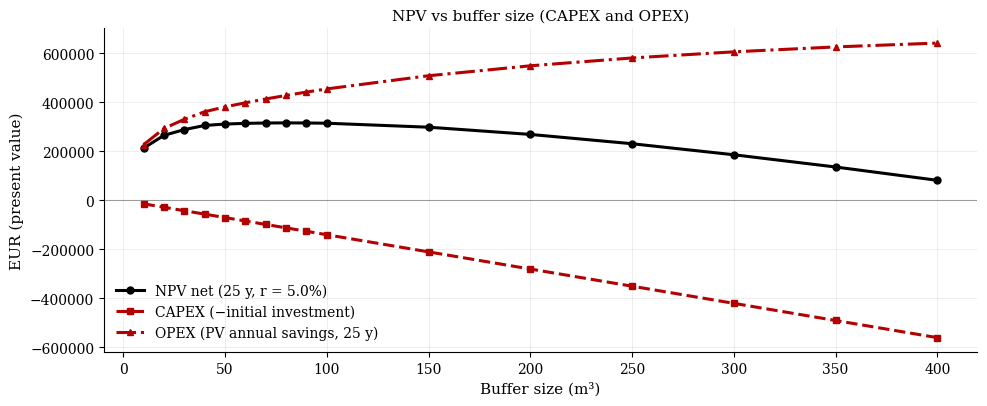

In [7]:
# Thesis-style figures: cost of heating and NPV vs buffer size
import sys
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import importlib

_src = str(Path("..") / "src")
if _src not in sys.path:
    sys.path.append(_src)

import buffer_size_sensitivity
importlib.reload(buffer_size_sensitivity)
from buffer_size_sensitivity import load_comparison_df_from_csvs, load_hp_economics

PROJECT_ROOT = Path("..").resolve()
OPT_OUTPUT_DIR = PROJECT_ROOT / "output" / "optimised_ts"

# Always rebuild from deterministic_hp_*m3.csv (no summary cache)
comparison_df = load_comparison_df_from_csvs(PROJECT_ROOT, output_dir=OPT_OUTPUT_DIR)

_econ = load_hp_economics(PROJECT_ROOT / "config" / "hp.yaml")
cost_of_capital = _econ["cost_of_capital"]
buffer_lifetime = _econ["buffer_lifetime"]

THESIS_STYLE = {
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "lines.linewidth": 2.2,
    "savefig.dpi": 300,
}
mpl.rcParams.update(THESIS_STYLE)

COL_BUFFER = "Buffer Size (m³)"
COL_COH = "Cost of Heating (EUR/MWh)"
COL_NPV = "NPV (EUR)"
COL_CAPEX = "CAPEX (EUR)"
COL_OPEX_ANNUAL = "Annual Savings (EUR)"

C_OPTIMIZED = "black"
C_UNCONTROLLED = "#b30000"
LW = 2.2

econ_plot = (
    comparison_df.loc[comparison_df[COL_BUFFER] != "Uncontrolled"]
    .assign(buffer_m3=lambda d: pd.to_numeric(d[COL_BUFFER], errors="coerce"))
    .dropna(subset=["buffer_m3"])
    .sort_values("buffer_m3")
)
uc_row = comparison_df.loc[comparison_df[COL_BUFFER] == "Uncontrolled"]

# --- Cost of heating vs buffer size ---
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.set_axisbelow(True)
ax.plot(
    econ_plot["buffer_m3"],
    pd.to_numeric(econ_plot[COL_COH], errors="coerce"),
    color=C_OPTIMIZED,
    linewidth=LW,
    marker="o",
    markersize=5,
    label="Optimized HP (deterministic MPC)",
)
if not uc_row.empty:
    uc_coh = float(pd.to_numeric(uc_row[COL_COH], errors="coerce").iloc[0])
    ax.axhline(
        uc_coh,
        color=C_UNCONTROLLED,
        linewidth=LW,
        linestyle="--",
        label=f"Uncontrolled HP ({uc_coh:.1f} EUR/MWh)",
    )
ax.set_xlabel("Buffer size (m³)")
ax.set_ylabel("Cost of heating (EUR/MWh)")
ax.set_title("Cost of heating vs buffer size")
ax.legend(frameon=False, loc="best")
fig.tight_layout()
plt.show()

# --- NPV vs buffer size (with CAPEX and OPEX components) ---
# NPV = −CAPEX + PV(annual operational savings); OPEX line = PV of annual savings


def _pv_annual_savings(annual: float, rate: float, years: int) -> float:
    if annual <= 0 or years <= 0:
        return 0.0
    return sum(annual / (1 + rate) ** t for t in range(1, years + 1))


econ_npv = econ_plot.assign(
    capex_eur=pd.to_numeric(econ_plot[COL_CAPEX], errors="coerce"),
    annual_savings_eur=pd.to_numeric(econ_plot[COL_OPEX_ANNUAL], errors="coerce"),
    npv_eur=pd.to_numeric(econ_plot[COL_NPV], errors="coerce"),
)
econ_npv["capex_plot_eur"] = -econ_npv["capex_eur"]
econ_npv["opex_pv_eur"] = econ_npv["annual_savings_eur"].apply(
    lambda a: _pv_annual_savings(float(a), cost_of_capital, buffer_lifetime)
)

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.set_axisbelow(True)
ax.axhline(0.0, color=C_OPTIMIZED, linewidth=0.8, alpha=0.35, zorder=1)

x = econ_npv["buffer_m3"]
ax.plot(
    x,
    econ_npv["npv_eur"],
    color=C_OPTIMIZED,
    linewidth=LW,
    marker="o",
    markersize=5,
    label=f"NPV net ({buffer_lifetime} y, r = {cost_of_capital * 100:.1f}%)",
)
ax.plot(
    x,
    econ_npv["capex_plot_eur"],
    color=C_UNCONTROLLED,
    linewidth=LW,
    linestyle="--",
    marker="s",
    markersize=4,
    label="CAPEX (−initial investment)",
)
ax.plot(
    x,
    econ_npv["opex_pv_eur"],
    color=C_UNCONTROLLED,
    linewidth=LW,
    linestyle="-.",
    marker="^",
    markersize=4,
    label=f"OPEX (PV annual savings, {buffer_lifetime} y)",
)
ax.set_xlabel("Buffer size (m³)")
ax.set_ylabel("EUR (present value)")
ax.set_title("NPV vs buffer size (CAPEX and OPEX)")
ax.legend(frameon=False, loc="best")
fig.tight_layout()
plt.show()
